In [1]:
import xradar as xd
import sys
import wradlib as wrl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import xarray as xr
import cmap
from scipy.ndimage import (
    median_filter,
    gaussian_filter,
    generic_filter,
    uniform_filter,
    label,
    generate_binary_structure,
    binary_closing,
    binary_opening,
)
from scipy.spatial import cKDTree
from pyproj import Transformer
import rioxarray
from rioxarray.merge import merge_datasets
from collections import OrderedDict
import s3fs
import io
import seaborn as sns
import json
from scipy.interpolate import interpn

In [2]:
# PLOTERS
###############################################################################

def plot_features(ax,labels_and_gridlines=False):
    departments = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='10m',
        edgecolor='gray',
        facecolor='never',
        linewidth=0.6,
        linestyle='-'
    )
    ax.add_feature(departments, zorder=3)
    #ax.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='blue', alpha=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='gray', alpha=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='gray', alpha=0.5)
    # Optional: add gridlines with labels
    if labels_and_gridlines:
        gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
        gl.top_labels = False
        gl.right_labels = False

In [3]:
# HELPERS
###############################################################################

def texture_std(x):

    valid = np.isfinite(x)

    if np.sum(valid) < 3:
        return np.nan

    return np.nanstd(x)

def compute_texture(field, size=(1, 5)):
    """
    Compute local texture of a radar field.
    """

    arr = field.values.copy()

    tex = generic_filter(
        arr,
        texture_std,
        size=size,
        mode="nearest"
    )

    return xr.DataArray(
        tex,
        dims=field.dims,
        coords=field.coords
    )

In [4]:

METEO_TABLE = {
    0 : "No data available",
    1 : "Non-meteorological target",
    2 : "Rain",
    3 : "Wet Snow",
    4 : "Snow",
    5 : "Graupel",
    6 : "Hail",
    7 : "Unused",
}

PRECIP_TABLE = {
    0 : "No data available",
    1 : "Ground clutter / anomalous propagation",
    2 : "Bio scatter",
    3 : "Precipitation",
    4 : "Large drops",
    5 : "Light precipitation",
    6 : "Moderate precipitation",
    7 : "Heavy precipitation",
}

CELL_TABLE = {
    0 : "Stratiform",
    1 : "Convection",
    2 : "Unused",
    3 : "Forbidden",
}

def decode_hclass(byte_val: int) -> tuple:
    if byte_val == 0:  # Reserved value for 'No Data'
        return (-2, -2, -2)
    if byte_val == 255:  # Reserved value for 'Area not scanned'
        return (np.nan, np.nan, np.nan)

    meteo_code = (byte_val >> 5) & 0x07
    precip_code = (byte_val >> 2) & 0x07
    cell_code = byte_val & 0x03

    return (meteo_code, precip_code, cell_code)

def decode_hclass_vect(raw_data: np.ndarray) -> np.ndarray:
    """Vectorized wrapper to decode an entire field."""
    return np.vectorize(decode_hclass, otypes=[object])(raw_data)

def get_(i, da):
    get = np.vectorize(lambda t: t[i])
    return xr.apply_ufunc(get, da)
#----------------------------------------------------------------------------------------

def open_iris_odict(filepath,load_data : bool = True, rawdata : bool =False, debug : bool =False):
    """
    Aquest funció només té raó d'ésser si wrl.io.iris.read_iris() no és capaç de decodificar la variable hclass.
    hclass conté un byte (8bits) que guarda la informació relativa a 3 classificadors
    """
    
    data_odict = wrl.io.iris.read_iris(
        filename=filepath,
        load=load_data,
        rawdata=rawdata,
        debug=debug,
    )
    return data_odict

def open_iris_dtree(filepath, decode_hclass : bool = True):
    """
    Aquest funció només té raó d'ésser si open_iris_datatree() no és capaç de decodificar la variable hclass.
    hclass conté un byte (8bits) que guarda la informació relativa a 3 classificadors
    """
    dt = xd.io.open_iris_datatree(filepath)
    
    if decode_hclass:
        dt["/sweep_0"]["DB_HCLASS"].values = decode_hclass_vect(dt["/sweep_0"]["DB_HCLASS"].values)
        dt["/sweep_0"]["DB_HCLASS_meteor"] = get_(0, dt["/sweep_0"]["DB_HCLASS"])
        dt["/sweep_0"]["DB_HCLASS_precip"] = get_(1, dt["/sweep_0"]["DB_HCLASS"])
        dt["/sweep_0"]["DB_HCLASS_storm"]  = get_(2, dt["/sweep_0"]["DB_HCLASS"])

    return dt

In [162]:
fs = s3fs.S3FileSystem(anon=True) 

# Ruta de tu archivo en el bucket
s3_path = "s3://s3-radaresideam/l2_data/2025/05/01/Tablazo/TAB250501012029.RAWFA8V"

# 2. Abrir el archivo de forma remota (Acceso instantáneo)
#remote_file = fs.open(s3_path, mode='rb') 
bytes_en_memoria = io.BytesIO(fs.cat(s3_path))

#filepath = "/media/cesc/NUEVO_USB/data/raw/Barrancabermeja/2025/11/20/BAR251120000005.RAWSAJB"
#filepath= "data/raw/Corozal/2024/11/09/COR241109000146.RAWRZXZ"
dtree = open_iris_dtree(bytes_en_memoria, decode_hclass=True)

swp = dtree["/sweep_0"]
print(swp)

<xarray.DataTree 'sweep_0'>
Group: /sweep_0
    Dimensions:            (sweep: 1, azimuth: 354, range: 664)
    Coordinates:
      * azimuth            (azimuth) float32 1kB 0.04944 1.019 2.068 ... 358.1 359.0
        elevation          (azimuth) float32 1kB ...
        time               (azimuth) datetime64[ns] 3kB 2025-05-01T01:20:52.74000...
      * range              (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
    Dimensions without coordinates: sweep
    Data variables: (12/17)
        DBTH               (azimuth, range) float32 940kB ...
        DBZH               (azimuth, range) float32 940kB ...
        VRADH              (azimuth, range) float32 940kB ...
        WRADH              (azimuth, range) float32 940kB ...
        ZDR                (azimuth, range) float32 940kB ...
        KDP                (azimuth, range) float32 940kB ...
        ...                 ...
        prt_mode           <U7 28B ...
        follow_mode        <U7 28B ...
        sweep_fix

In [163]:
radar_alt = float(dtree["/"]["altitude"].values)
radar_lon = float(dtree["/"]["longitude"].values)
radar_lat = float(dtree["/"]["latitude"].values)

site = (radar_lon, radar_lat, radar_alt)

azimuth   = swp["azimuth"].data
range     = swp["range"].data
elangle   = swp["elevation"].data

print(elangle)

azimuth_2d, range_2d = np.meshgrid(azimuth, range, indexing='ij')
elevation_2d = np.broadcast_to(elangle[:,np.newaxis], azimuth_2d.shape)

xyz,aeqd = wrl.georef.polar.spherical_to_xyz(
    range_2d,
    azimuth_2d,
    elevation_2d,
    site,
)

x = xyz[...,0]
y = xyz[...,1]
z = xyz[...,2]

transformer = Transformer.from_crs(
    aeqd,
    "EPSG:4326",
    always_xy=True,
)
lon,lat = transformer.transform(x,y)
alt = z

radar_lon = np.squeeze(lon)
radar_lat = np.squeeze(lat)
radar_z = np.squeeze(z)

swp.coords["gate_latitude"] = (('azimuth', 'range'), radar_lat)
swp.coords["gate_longitude"] = (('azimuth', 'range'), radar_lon)
swp.coords["gate_height"] = (('azimuth', 'range'), radar_z)

print(dtree)
print(swp.data_vars)

[0.48339844 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844
 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844
 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844
 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844
 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844
 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844
 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844
 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844
 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844
 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844
 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844
 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844
 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844
 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844
 0.48339844 0.48339844 0.48339844 0.48339844 0.48339844 0.4833

In [164]:
alpha=0.01
texture_thresh=22.5
zdr_thresh=7
dr_thresh=-12.0

In [165]:
DBZH = swp["DBZH"]
PHIDP = swp["PHIDP"]
KDP = swp["KDP"]
RHOHV = swp["RHOHV"]
ZDR = swp["ZDR"]

In [166]:
gate_latitude  = swp.coords["gate_latitude"].values
gate_longitude = swp.coords["gate_longitude"].values
gate_height    = swp.coords["gate_height"].values

In [167]:
filename1 = "10s090w_20101117_gmted_mea075.tif"
filename2 = "10n090w_20101117_gmted_mea075.tif"

# 1. Obrim els dos fitxers de la USGS directament
dem1 = xr.open_dataset(filename1, engine="rasterio")
dem2 = xr.open_dataset(filename2, engine="rasterio")

# Fusionem amb la funció de rioxarray merge per cobrir tot el territori colombià (Nord i Sud)
dem = merge_datasets([dem1, dem2])

# Extreure la banda d'elevació principal
elevation_raw = dem.band_data.sel(band=1)

# !!! SEGURETAT 1 !!! 
# Evitem que l'oceà o les zones sense dades (NaN o valors negatius arbitraris) 
# actuïn com a "murs virtuals" col·locant una cota mínima segura profunda (-500m).
elevation = elevation_raw.where(elevation_raw > -100, -500.0)

In [168]:
dem_lon = dem.x.values
dem_lat = dem.y.values

# Si les latituds van de nord a sud (valors decreixents), invertim l'eix i la matriu 
# perquè interpn necessita obligatòriament vectors estrictament creixents
if dem_lat[0] > dem_lat[-1]:
    dem_lat = dem_lat[::-1]
    dem_values = elevation.values[::-1, :]
else:
    dem_values = elevation.values

# Guardem la forma (shape) 2D original del radar (ex: 360 azimuts x 1200 gats)
forma_original_radar = gate_latitude.shape

# Creem la llista de punts de destinació per a l'interpn en format flat (aplanat)
punts_radar = np.stack((gate_latitude, gate_longitude), axis=-1).reshape(-1, 2)

# Executem la interpolació lineal de dades
terrain_height_flat = interpn(
    (dem_lat, dem_lon), 
    dem_values, 
    punts_radar, 
    method="linear", 
    bounds_error=False, 
    fill_value=-500.0 # Fora de mapa es considera buit profund (mai bloqueja)
)

# !!! CORRECCIÓ CRÍTICA DE DIMENSIONS !!!
# Tornem a donar-li la forma 2D (azimuth, range) per estar en perfecta sincronia amb gate_height
terrain_height = terrain_height_flat.reshape(forma_original_radar)

# Netegem potencials NaNs residuals que hagin pogut escapar
terrain_height = np.nan_to_num(terrain_height, nan=-500.0)

In [169]:
beamwidth = 1.0
r_distances = swp.coords["range"].values

# Calculem el radi geomètric del feix a cada metre de distància
beamradius = wrl.util.half_power_radius(r_distances, beamwidth)

# !!! SEGURETAT 2: EQUILIBRI DE LA TORRE DEL RADAR !!!
# L'antena de Corozal no està arran de terra, té una torre que la separa de la base.
# Si gate_height és exactament igual o inferior al terreny local per mil·límetres numèrics, 
# wradlib generarà un bloqueig destructiu. Afegim un llindar de tolerància física.
gate_height_corregit = gate_height.copy()

# Executem el càlcul natiu de la fracció de bloqueig parcial cel·la a cel·la (PBB)
pbb = wrl.qual.beam_block_frac(terrain_height, gate_height_corregit, beamradius)

# !!! SEGURETAT 3: FILTRE ANTIFALSOS EN COSTA I MARE !!!
# A. Si la cota de terreny és negativa o zero (el mar, zones costaneres planes o vores del DEM), 
# el bloqueig físic real és ZERO absolut.
pbb[terrain_height <= 0.0] = 0.0

# B. Si el centre del feix està volant molt per sobre de la muntanya i el radi inferior 
# no frega la cota del terreny, forcem que el bloqueig sigui 0.0 de forma neta.
pbb[gate_height_corregit > (terrain_height + beamradius)] = 0.0

# C. Protecció del voltant immediat del radar (fins a 3 km de distància): 
# Evita que interferències properes a la llanura de Corozal iniciïn un bloqueig perpetu.
# Creem una matriu 2D de distàncies temporals
_, range_2d_temp = np.meshgrid(swp["azimuth"].data, r_distances, indexing='ij')
pbb[range_2d_temp < 3000.0] = 0.0

# Calculem el bloqueig acumulatiu progressiu al llarg de cada raig (CBB)
pbb_masked = np.ma.masked_invalid(pbb)
cbb = wrl.qual.cum_beam_block_frac(pbb_masked)

# Omplim buits amb 0 (sense bloqueig)
cbb = np.ma.filled(cbb, fill_value=0.0)

# Injectem les dades netes al DataArray de xarray respectant les coordenades
swp["CBB"] = xr.DataArray(
    cbb, 
    dims=["azimuth", "range"],
    coords={
        "azimuth": swp["azimuth"],
        "range": swp["range"]
    }
)

swp["CBB"].attrs["long_name"] = "Cumulative Beam Blockage Fraction"
swp["CBB"].attrs["units"] = "1"
swp["CBB"].attrs["comment"] = "Calculat mitjançant fusió estricta de dos DEMs USGS corregits per a la llanura del Carib."

print("Càlcul de Bloqueig Completat amb èxit!")
print(f"Valors de bloqueig totals (>0.5): {np.sum(cbb > 0.5)} cel·les.")

Càlcul de Bloqueig Completat amb èxit!
Valors de bloqueig totals (>0.5): 3170 cel·les.


/home/cesc/anaconda3/envs/radar-env/lib/python3.11/site-packages/wradlib/qual.py:181: RuntimeWarning: invalid value encountered in sqrt
  numer = (ya * np.sqrt(a**2 - y**2)) + (a * np.arcsin(ya)) + (np.pi * a / 2.0)
/home/cesc/anaconda3/envs/radar-env/lib/python3.11/site-packages/wradlib/qual.py:181: RuntimeWarning: invalid value encountered in arcsin
  numer = (ya * np.sqrt(a**2 - y**2)) + (a * np.arcsin(ya)) + (np.pi * a / 2.0)


In [170]:
dbzh = DBZH.values
cbb = swp["CBB"].values
print(np.unique_counts(cbb))

dbzh_corr = np.copy(dbzh)

mask_comp = (cbb >= 0.1) & (cbb <= 0.5)

dbzh_corr[mask_comp] = dbzh_corr[mask_comp] - 10.0 * np.log10(1.0 - cbb[mask_comp])

mask_elim = cbb > 0.5
dbzh_corr[mask_elim] = np.nan

DBZH_terrain_corr = xr.DataArray(dbzh_corr, dims=["azimuth", "range"])


UniqueCountsResult(values=array([0.00000000e+00, 2.84723045e-05, 8.43273000e-05, 2.98473637e-04,
       3.39200917e-04, 1.23415438e-03, 1.37721734e-03, 2.47936363e-03,
       2.93280198e-03, 3.18303278e-03, 3.66323560e-03, 3.71805267e-03,
       6.29557177e-03, 7.04955676e-03, 7.21908759e-03, 8.99141486e-03,
       1.09921935e-02, 1.26763240e-02, 1.47988670e-02, 1.59800064e-02,
       1.78597858e-02, 2.07261713e-02, 2.34572154e-02, 2.90050745e-02,
       2.97451841e-02, 3.11718988e-02, 3.14059694e-02, 3.30854051e-02,
       3.45108063e-02, 3.56538818e-02, 3.91426979e-02, 4.00567850e-02,
       4.12615975e-02, 4.17589555e-02, 4.68246721e-02, 4.81829793e-02,
       5.06356893e-02, 5.13121071e-02, 6.07583311e-02, 6.18242710e-02,
       6.25614597e-02, 6.54251452e-02, 6.69000911e-02, 6.80291832e-02,
       7.05007164e-02, 7.16930627e-02, 7.39867091e-02, 8.23717254e-02,
       8.53706863e-02, 8.70526832e-02, 9.56693933e-02, 1.02538269e-01,
       1.03250513e-01, 1.19288031e-01, 1.21790904e-

In [171]:
textura_phidp = wrl.util.texture(PHIDP.values)
textura_phidp = np.nan_to_num(textura_phidp, nan=0.0)

tPHIDP = xr.DataArray(
    textura_phidp,
    dims=PHIDP.dims,
    coords=PHIDP.coords
)

In [172]:

# 1. RECUPERAR LES MATRIUS DES DEL TEU SWEEP
# Assegura't que els noms coincideixen amb les variables de dades del teu DataTree
dbzh = DBZH_terrain_corr.values     # Reflectivitat horitzontal en dBZ
zdr_db = ZDR.values    # Reflectivitat diferencial en dB
rhohv = RHOHV.values    # Coeficient de correlació creuada (0 a 1)

# 2. CALCULAR ELS COMPONENTS EN ESCALA LINEAL DE L'EQUACIÓ DE KILAMBI
# Transformació de dB a lineal de ZDR i de l'arrel quadrada (ZDR^0.5)
zdr_linear = 10.0 ** (zdr_db / 10.0)
zdr_sqrt_linear = 10.0 ** (zdr_db / 20.0)

# 3. EXECUTAR L'EQUACIÓ COMPLETA DEL DR
# Calculem el numerador i el denominador de la ràtio de despolarització
numerador = zdr_linear + 1.0 - (2.0 * zdr_sqrt_linear * rhohv)
denominador = zdr_linear + 1.0 + (2.0 * zdr_sqrt_linear * rhohv)

# Evitar divisions per zero si el denominador és nul o invàlid
with np.errstate(divide='ignore', invalid='ignore'):
    dr_linear = numerador / denominador
    # El paper finalment passa el resultat a escala logarítmica (dB)
    dr_db = 10.0 * np.log10(dr_linear)

# Substituir potencials valors infinits o nuls per un valor neutre baix
#dr_db = np.nan_to_num(dr_db, nan=99.0, posinf=99.0, neginf=99.0)

# ==========================================================
# 4. APLICAR ELS LLINDARS DE TALL DEL PAPER (HARD MASKING)
# ==========================================================
# Segons Kilambi et al. (2018), els hidrometeors (pluja real) tenen valors 
# de DR molt baixos (normalment inferiors a -12 dB o -15 dB).
# Els insectes, clutter i soroll urbà solen tenir valors de DR superiors a -10 dB.

# Creem la màscara dura (True = Esborrar cel·la per no-meteorològica)
llindar_tall = -12.0
mascara_no_meteo = (dr_db < llindar_tall) & (dbzh < 30)

# 5. INTEGRAR LA NOVA VARIABLE AL TEU DATATREE
swp["DR"] = xr.DataArray(dr_db, dims=["azimuth","range"])
swp["DR"].attrs["long_name"] = "Dual-Polarization Depolarization Ratio"
swp["DR"].attrs["units"] = "dB"

print("Variable DR calculada amb èxit!")
print(f"Cel·les detectades com a soroll/insectes (DR > {llindar_tall} dB): {np.sum(~mascara_no_meteo)}")

Variable DR calculada amb èxit!
Cel·les detectades com a soroll/insectes (DR > -12.0 dB): 219144


/home/cesc/anaconda3/envs/radar-env/lib/python3.11/site-packages/xradar/io/backends/iris.py:254: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(decode_array(data, **kwargs))


In [173]:
DR = swp["DR"].fillna(0.0)
CBB = swp["CBB"].fillna(0.0)

In [174]:
no_met_mask = (
      ((DR > dr_thresh)          & (DBZH < 35.0))
    | ((tPHIDP > texture_thresh) & (DBZH < 35.0))
    | (DBZH <= 0)
    | (CBB == 1.0)
)

raw_clutter_flags = no_met_mask.values

# Using a 4-connectivity cross avoids excessive distortion along radial cell boundaries
structure = generate_binary_structure(rank=2, connectivity=1)

# B. Opening: Targets and erases single-pixel transient speckles across clean areas
clean_clutter_mask = binary_opening(raw_clutter_flags, structure=structure, iterations=1)

met_mask_vals = ~clean_clutter_mask

met_mask = xr.DataArray(
    met_mask_vals,
    dims=swp.DBZH.dims,
    coords=swp.DBZH.coords,
    attrs={
        "long_name": "Consolidated Meteorological Quality Mask",
        "description": "Binary mask generated via multi-variable thresholds and refined with a Close-Open morphological sequence."
    }
)

#met_mask = met_mask.reindex_like(DBZH, fill_value=True)

swp["met_mask"] = met_mask

In [175]:
fDBZH = xr.where(
    met_mask,
    DBZH_terrain_corr,
    np.nan
)

max_interpolation_gap = 8

# Interpolació per a la Reflectivitat
fDBZH = fDBZH.interpolate_na(
    dim="range", 
    method="linear", 
    max_gap=max_interpolation_gap
)

fZDR = xr.where(
    met_mask,
    ZDR,
    np.nan
)
# Interpolació per a la Reflectivitat Diferencial
fZDR = fZDR.interpolate_na(
    dim="range", 
    method="linear", 
    max_gap=max_interpolation_gap
)

fPHIDP = xr.where(
    met_mask,
    PHIDP,
    np.nan
)

In [176]:
# Suposem que 'fPHIDP' és el teu DataArray original amb els NaNs de la textura
phidp_inicial = fPHIDP.copy()

# ===========================================================================
# PAS 2: FILTRE DE MEDIANA EN 2D (Eliminació de soroll d'impuls / valors atípics)
# ===========================================================================
# Escaneja la matriu cel·la per cel·la aplicant una finestra radial de 5 píxels.
# S'executa en NumPy pur sobre els valors interpolats.
vals_mediana = median_filter(
    phidp_inicial.values,
    size=(1, 5)
)

# Reconstruïm el DataArray per poder aplicar les funcions geomètriques de xarray
phidp_mediana = xr.DataArray(
    vals_mediana,
    dims=phidp_inicial.dims,
    coords=phidp_inicial.coords
)

# ===========================================================================
# PAS 3: MITJANA MÒBIL RADIAL ADAPTATIVA (Suavitzat final de la línia base)
# ===========================================================================
# Apliquem una finestra de 25 cel·les per homogeneïtzar la fase abans de derivar.
# SOLUCIÓ CRÍTICA: 'min_periods=1' impedeix que els NaNs grans (com muntanyes esborrades)
# es propaguin com una taca d'oli i destrueixin les zones de pluja neta.
sPHIDP = phidp_mediana.rolling(
    range=25,
    center=True,
    min_periods=1
).mean()


# ===========================================================================
# PAS 4: BLOCATGE DE SEGURETAT FINAL PER A WRADLIB (fillna)
# ===========================================================================
# L'algorisme de convolució de Lanczos de wradlib llançarà un error matemàtic
# si troba algun NaN residual a la matriu. Omplim els NaNs que hagin quedat
# (exclusivament a les zones de cel completament buit a la perifèria) amb 0.0.
sPHIDP_clean = sPHIDP.fillna(0.0)


swp["aPHIDP"] = phidp_inicial



In [177]:
# 1. Agafem la variable del pas anterior (el suavitzat adaptatiu)
vals = np.copy(sPHIDP_clean.values)

# ===========================================================================
# PAS 9: FORÇAT DE MONOTONICITAT (Justificació: Hubbert & Bringi, 1995)
# ===========================================================================
# Corregim cel·la per cel·la al llarg de cada raig d'azimut per assegurar 
# que la fase mai decreix i eliminem el risc de KDP negatiu.
for az in np.arange(vals.shape[0]):
    ray = vals[az]
    for i in np.arange(1, len(ray)):
        if np.isfinite(ray[i-1]) and np.isfinite(ray[i]):
            if ray[i] < ray[i-1]:
                ray[i] = ray[i-1]
    vals[az] = ray

# ===========================================================================
# PAS 10: FILTRES DE MEDIANA FINALS (Poliment de la línia creixent)
# ===========================================================================
# Apliquem la seqüència exacta de filtres de mediana del teu codi (mida 4 i 8)
# per eliminar qualsevol graó artificial generat pel bucle de monotonicitat.
vals = median_filter(vals, size=(1, 4))
vals = median_filter(vals, size=(1, 8))

# ===========================================================================
# PAS 11: RECONSTRUCCIÓ DE LA VARIABLE I MÀSCARA METEOROLÒGICA
# ===========================================================================
# Apliquem de forma estricta la teva màscara de control de qualitat (met_mask)
# per assegurar-nos que fora de les zones de pluja el mapa quedi net (NaN).
vals_with_nan = np.copy(vals)
vals_with_nan[~met_mask.values] = np.nan

sPHIDP = xr.DataArray(
    vals_with_nan,
    dims=fPHIDP.dims,
    coords=fPHIDP.coords
)

In [178]:
###########################################################################
# 10. CLEAN KDP
###########################################################################

cKDP = xr.where(
    met_mask,
    KDP,
    np.nan
)

In [179]:
r_metres = swp.coords["range"].values
resolucio_metres = r_metres[1] - r_metres[0]  # Això sol donar 62.5m o 125m segons el radar

# 2. CONVERTIR HO A QUILÒMETRES (Requisit físic del KDP)
dr_km = resolucio_metres / 1000.0
print(f"Resolució espacial del radar detectada: {resolucio_metres} metres ({dr_km} km)")
# ===========================================================================
# 1. CÀLCUL DEL KDP AMB LA FUNCIÓ OFICIAL DE WRADLIB
# ===========================================================================
# Enviem la matriu 'vals' (que prové del forçat de monotonicitat, 100% numèrica)
# Usem 'winlen=24' perquè és la longitud de finestra òptima per a la Banda X de Bogotà
# i el mètode 'lanczos_conv' que aplica una derivada de convolució d'alta precisió.
dKDP_calculat = wrl.dp.kdp_from_phidp(
    sPHIDP.values, 
    winlen=25,
    dr=dr_km,
    method="lanczos_conv"
)

# ===========================================================================
# 2. POST-NETEJA CRÍTICA (POST-PROCESSING) DEL KDP
# ===========================================================================

# --- Pas A: Eliminació de valors negatius artificials ---
# Per la física del radar, la fase només augmenta, per tant el KDP real ha de ser positiu.
# Els petits valors negatius són artefactes matemàtics de la convolució a les vores de la pluja.
# Els forcem a 0.0 de forma segura.
dKDP_net = np.where(dKDP_calculat < 0.0, 0.0, dKDP_calculat)

# --- Pas B: Filtre de Mediana final per homogeneïtzar els nuclis ---
# Apliquem un filtre de mediana suau radial (mida 3) per netejar qualsevol "pic elèctric" 
# o valor extrem aïllat generat durant la derivació numèrica.
dKDP_net = median_filter(dKDP_net, size=(1, 3))

# --- Pas C: Aplicació del Hard Masking de la màscara meteorològica ---
# Recuperem la teva màscara de control de qualitat (met_mask) per assegurar-nos que
# tot el cel buit, zones de soroll de fons o muntanyes severes quedin com a NaN.
dKDP_final = np.copy(dKDP_net)
dKDP_final[~met_mask.values] = np.nan

dKDP = xr.DataArray(
    dKDP_final,
    dims=cKDP.dims,
    coords=cKDP.coords,
)

Resolució espacial del radar detectada: 450.0 metres (0.44999998807907104 km)


In [180]:
###########################################################################
# 11. SPECIFIC ATTENUATION
###########################################################################

#A = alpha * cKDP
A = alpha * dKDP

###########################################################################
# 12. RANGE RESOLUTION
###########################################################################

dr = float(
    swp["range"][1] - swp["range"][0]
)

dr_km = dr / 1000.0

###########################################################################
# 13. PIA
###########################################################################

pia_vals = 2 * np.nancumsum(
    A.values * dr_km,
    axis=1
)

PIA = xr.DataArray(
    pia_vals,
    dims=A.dims,
    coords=A.coords
)

###########################################################################
# 14. ATTENUATION CORRECTED REFLECTIVITY
###########################################################################

cDBZH_attcorr = fDBZH + PIA

###########################################################################
# 15. RAINFALL ESTIMATION
###########################################################################

# R(A)
R_A = 4120 * (A ** 1.03)

# R(KDP)
#R_KDP = 30.62 * (cKDP ** 0.78)
R_KDP = 30.62 * (dKDP ** 0.78)

R_Z = (10**(cDBZH_attcorr/10)/180)**(1/1.4)

In [181]:
swp["met_mask"] = met_mask

swp["sPHIDP"] = sPHIDP
swp["sPHIDP"].attrs["long_name"] = "Smoothed Phase Shift (PhiDP)"
swp["sPHIDP"].attrs["units"] = "degrees"

swp["tPHIDP"] = tPHIDP

swp["DBZH_terrain_corr"] = DBZH_terrain_corr
swp["DBZH_terrain_corr"].attrs["long_name"] = "Reflectivity corrected for beam blockage"
swp["DBZH_terrain_corr"].attrs["units"] = "dBZ"

swp["fPHIDP"] = fPHIDP

swp["cKDP"] = cKDP

swp["dKDP"] = dKDP

swp["cZDR"] = fZDR

swp["A"] = A

swp["PIA"] = PIA

swp["cDBZH"] = cDBZH_attcorr

swp["R_A"] = R_A
swp["R_KDP"] = R_KDP

swp["R_Z"] = R_Z

In [ ]:
filename1 = "10s090w_20101117_gmted_mea075.tif"
filename2 = "10n090w_20101117_gmted_mea075.tif"
print(site)

# 1. Open the raster directly with rioxarray
dem1 = xr.open_dataset(filename1, engine="rasterio")
dem2 = xr.open_dataset(filename2, engine="rasterio")

dem = merge_datasets([dem1, dem2])

AttributeError: 'function' object has no attribute 'isnull'

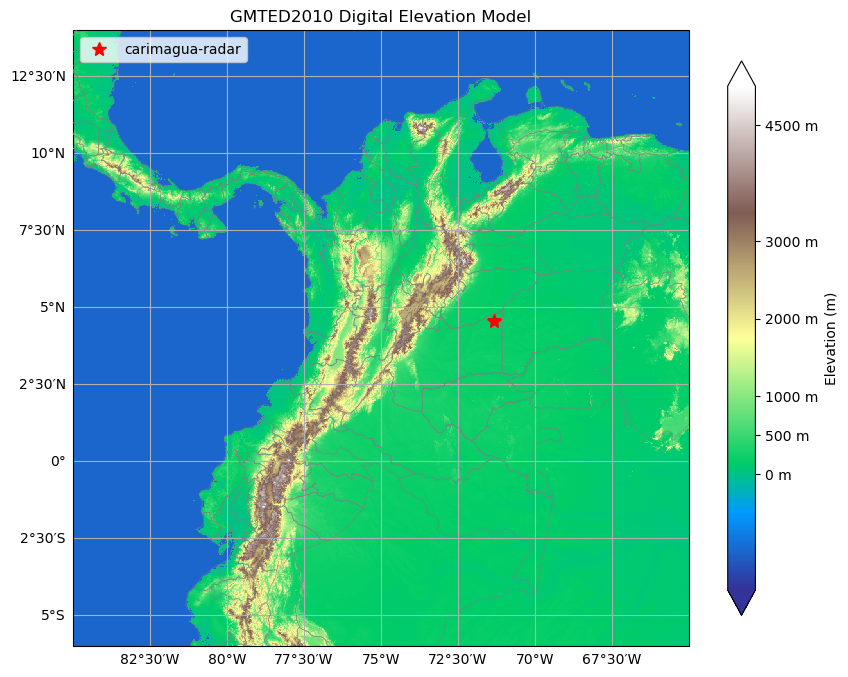

In [78]:
elevation = dem.band_data.sel(band=1)

elevation = elevation.isel(x=slice(0, None, 10), y=slice(0, None, 10))

elevation = elevation.where(elevation > 0,-1000)

# 2. Create your map plot
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot(111, projection=ccrs.PlateCarree())
plot_features(ax,labels_and_gridlines=True)

ax.set_extent([-85, -65, -6, 14], crs=ccrs.PlateCarree())

# 3. Plot the data using xarray's native matplotlib wrapper
el = elevation.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='terrain', vmin=-1500, vmax=5000,
        cbar_kwargs={
                'label'      : 'Elevation (m)',                  # Títol de la barra de colors
                'orientation': 'vertical',                       # Orientació ('horizontal' o 'vertical')
                'shrink'     : 0.9,                              # Redueix la mida de la barra (0.7 = 70%)
                'pad'        : 0.05,                             # Espai entre el mapa i la barra (més petit = més a prop)
                'extend'     : 'both',                           # Posa fletxes als extrems (valors fora de rang: 'neither', 'both', 'min', 'max')
                'format'     : '%d m',                           # Format dels números (en aquest cas, enters seguits de "m")
                'ticks'      : [0, 500, 1000, 2000, 3000, 4500], # Força quines etiquetes numèriques es mostren
        })


ax.plot(dtree.longitude, dtree.latitude, 'r*', markersize=10, 
        transform=ccrs.PlateCarree(), label=f'{dtree.attrs["instrument_name"]}')

plt.title('GMTED2010 Digital Elevation Model')
plt.legend(loc='upper left')
plt.show()

In [182]:
number_of_colors = 30

In [183]:
var = "DB_HCLASS_meteor"

<xarray.DataArray 'DB_HCLASS_meteor' (azimuth: 354, range: 664)> Size: 2MB
array([[-2, -2, -2, ..., -2, -2, -2],
       [-2, -2, -2, ..., -2, -2, -2],
       [-2, -2, -2, ..., -2, -2, -2],
       ...,
       [-2, -2, -2, ..., -2, -2, -2],
       [-2, -2, -2, ..., -2, -2, -2],
       [-2, -2,  3, ..., -2, -2, -2]], shape=(354, 664))
Coordinates:
  * azimuth         (azimuth) float32 1kB 0.04944 1.019 2.068 ... 358.1 359.0
    elevation       (azimuth) float64 3kB 0.4834 0.4834 0.4834 ... 0.4834 0.4834
    time            (azimuth) datetime64[ns] 3kB 2025-05-01T01:20:52.740000 ....
  * range           (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
    gate_latitude   (azimuth, range) float64 2MB 5.015 5.019 ... 7.705 7.709
    gate_longitude  (azimuth, range) float64 2MB -74.2 -74.2 ... -74.25 -74.25
    gate_height     (azimuth, range) float64 2MB 3.547e+03 3.55e+03 ... 1.13e+04


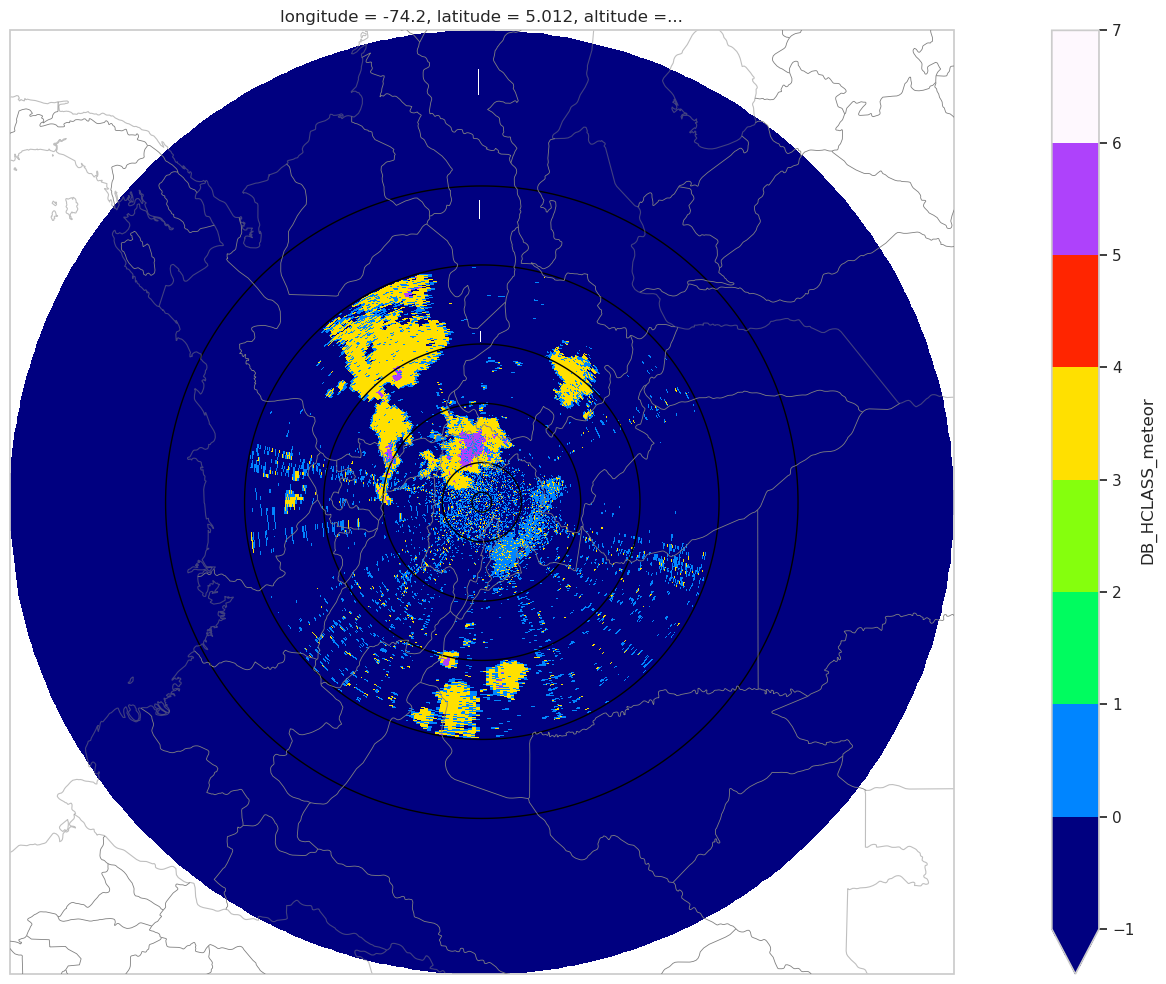

In [184]:
da = swp[f"{var}"]

print(da)

da["range"] = da["range"].values*2 #Realment no és així
da.attrs["sweep_mode"] = swp["sweep_mode"].values
da.coords["longitude"] = dtree["longitude"].values
da.coords["latitude"] = dtree["latitude"].values
da.coords["altitude"] = dtree["altitude"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=-1,
    vmax=7,
    cmap=cmap.Colormap("ncar").to_mpl(8),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)

wrl.vis.plot_ppi_crosshair(
    site=site,
    ranges=[12500,50000,125000,200000,300000,400000],
    line={"color": "None"},
    circle={"edgecolor": "black", "linewidth" : 1, "linestyle" : "-"},
    ax=ax,
    crs=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
)

plt.tight_layout()
plt.show()

In [189]:
var = "cDBZH"

<xarray.DataArray 'cDBZH' (azimuth: 354, range: 664)> Size: 2MB
array([[-32.        ,          nan,          nan, ...,          nan,
                 nan, -31.6093707 ],
       [         nan,          nan,          nan, ...,          nan,
                 nan,          nan],
       [         nan,          nan,          nan, ...,          nan,
                 nan,          nan],
       ...,
       [         nan,          nan,          nan, ...,          nan,
                 nan,          nan],
       [         nan,          nan,          nan, ...,          nan,
                 nan,          nan],
       [-32.        ,          nan,          nan, ...,          nan,
                 nan, -31.57373508]], shape=(354, 664))
Coordinates:
  * azimuth         (azimuth) float32 1kB 0.04944 1.019 2.068 ... 358.1 359.0
    elevation       (azimuth) float64 3kB 0.4834 0.4834 0.4834 ... 0.4834 0.4834
    time            (azimuth) datetime64[ns] 3kB 2025-05-01T01:20:52.740000 ....
  * range       

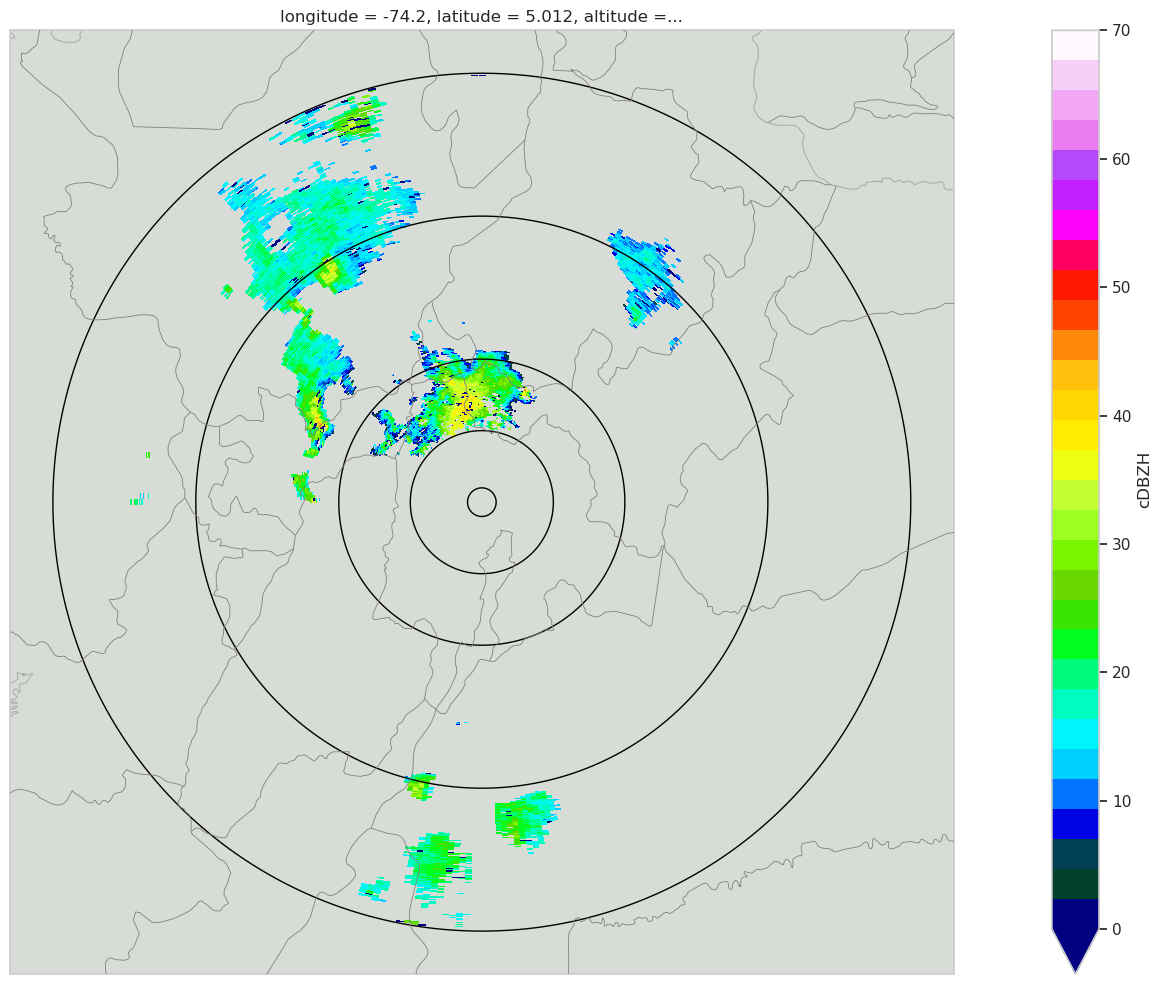

In [190]:
#da = xr.where(met_mask, swp[f"{var}"], np.nan)
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da.coords["longitude"] = dtree["longitude"].values
da.coords["latitude"] = dtree["latitude"].values
da.coords["altitude"] = dtree["altitude"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

ax.set_facecolor('xkcd:light gray')   

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=70,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)

wrl.vis.plot_ppi_crosshair(
    site=site,
    ranges=[10000,50000,100000,200000,300000],
    line={"color": "None"},
    circle={"edgecolor": "black", "linewidth" : 1, "linestyle" : "-"},
    ax=ax,
    crs=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
)

plt.tight_layout()
plt.show()

In [187]:
var = "cZDR"

<xarray.DataArray 'cZDR' (azimuth: 354, range: 664)> Size: 2MB
array([[-7.9375,     nan,     nan, ...,     nan,     nan, -8.    ],
       [    nan,     nan,     nan, ...,     nan,     nan,     nan],
       [    nan,     nan,     nan, ...,     nan,     nan,     nan],
       ...,
       [    nan,     nan,     nan, ...,     nan,     nan,     nan],
       [    nan,     nan,     nan, ...,     nan,     nan,     nan],
       [-7.9375,     nan,     nan, ...,     nan,     nan, -8.    ]],
      shape=(354, 664))
Coordinates:
  * azimuth         (azimuth) float32 1kB 0.04944 1.019 2.068 ... 358.1 359.0
    elevation       (azimuth) float64 3kB 0.4834 0.4834 0.4834 ... 0.4834 0.4834
    time            (azimuth) datetime64[ns] 3kB 2025-05-01T01:20:52.740000 ....
  * range           (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
    gate_latitude   (azimuth, range) float64 2MB 5.015 5.019 ... 7.705 7.709
    gate_longitude  (azimuth, range) float64 2MB -74.2 -74.2 ... -74.25 -74.25
    gat

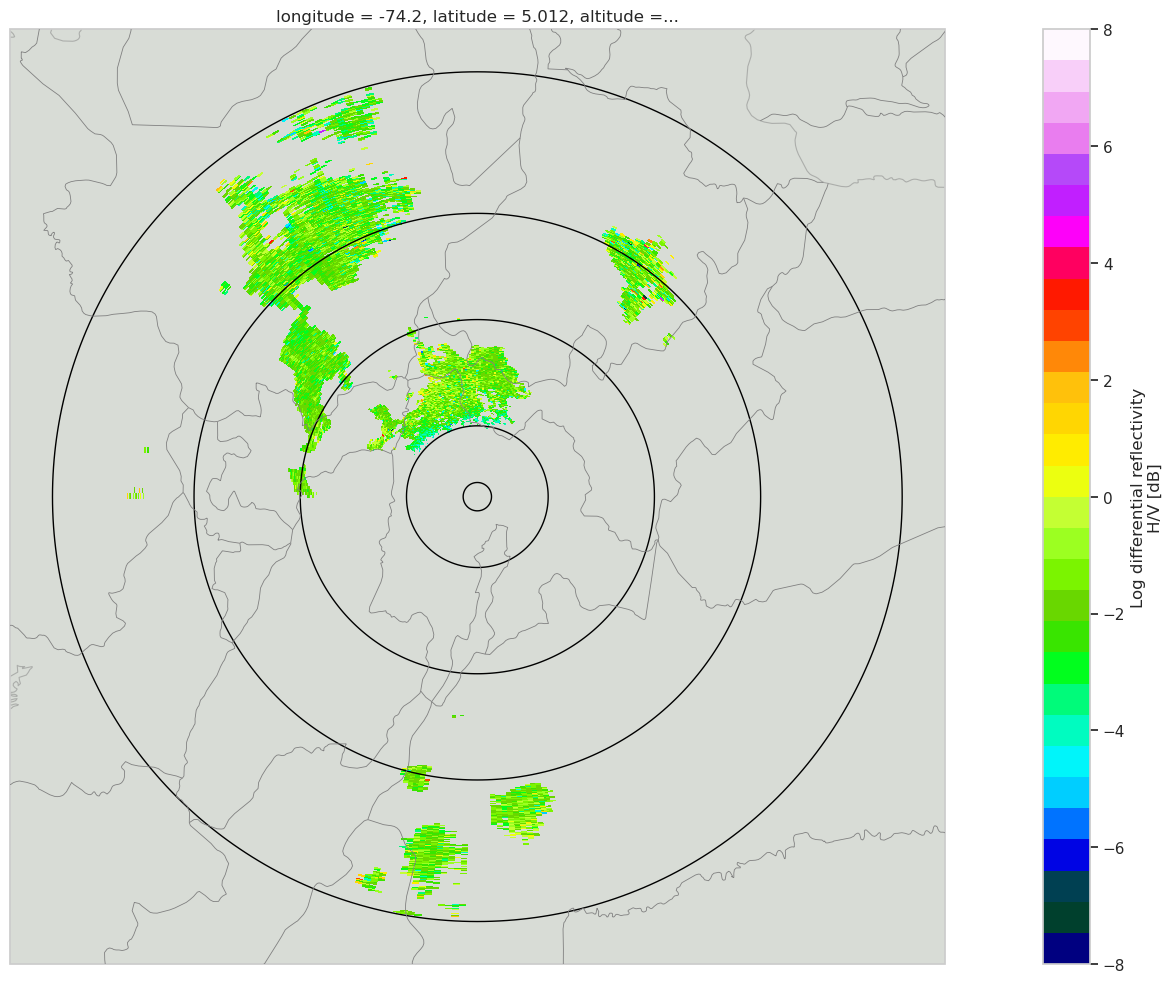

In [188]:
da = swp[f"{var}"]
#da = da.fillna(0.0)
print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da.coords["longitude"] = dtree["longitude"].values
da.coords["latitude"] = dtree["latitude"].values
da.coords["altitude"] = dtree["altitude"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

ax.set_facecolor('xkcd:light gray')   

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)

wrl.vis.plot_ppi_crosshair(
    site=site,
    ranges=[10000,50000,125000,200000,300000],
    line={"color": "None"},
    circle={"edgecolor": "black", "linewidth" : 1, "linestyle" : "-"},
    ax=ax,
    crs=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
)

plt.tight_layout()
plt.show()

In [191]:
var1 = "PHIDP"
var2 = "fPHIDP"
var3 = "sPHIDP"

<xarray.DataArray 'PHIDP' (azimuth: 354, range: 664)> Size: 940kB
[235056 values with dtype=float32]
Coordinates:
  * azimuth         (azimuth) float32 1kB 0.04944 1.019 2.068 ... 358.1 359.0
    elevation       (azimuth) float64 3kB 0.4834 0.4834 0.4834 ... 0.4834 0.4834
    time            (azimuth) datetime64[ns] 3kB 2025-05-01T01:20:52.740000 ....
  * range           (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
    gate_latitude   (azimuth, range) float64 2MB 5.015 5.019 ... 7.705 7.709
    gate_longitude  (azimuth, range) float64 2MB -74.2 -74.2 ... -74.25 -74.25
    gate_height     (azimuth, range) float64 2MB 3.547e+03 3.55e+03 ... 1.13e+04
Attributes:
    units:          degrees
    standard_name:  radar_differential_phase_hv
    long_name:      Differential phase HV
[ -0.70866142   0.           0.70866142   1.41732283   2.12598425
   2.83464567   3.54330709   4.2519685    4.96062992   5.66929134
   6.37795276   7.08661417   7.79527559   8.50393701   9.21259843
   9.

/tmp/ipykernel_12806/1125768952.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


[]

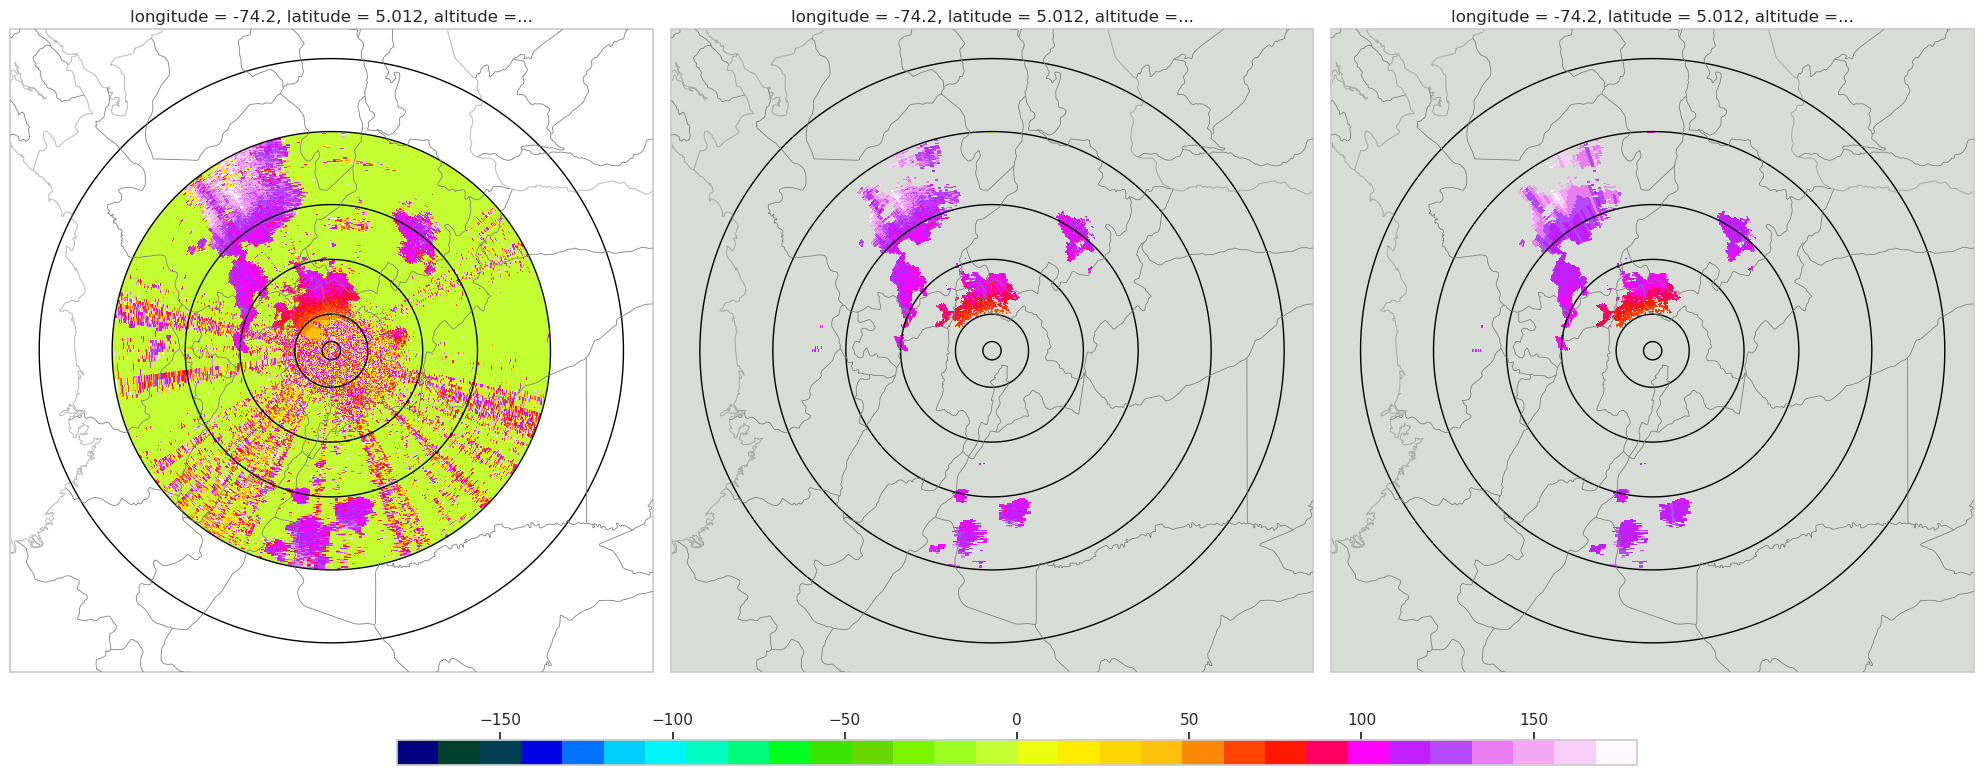

In [ ]:
da1 = swp[f"{var1}"]

print(da1)
print(np.unique_values(da1.values[~np.isnan(da1.values)]))

da1.attrs["sweep_mode"] = swp["sweep_mode"].values
da1.coords["longitude"] = dtree["longitude"].values
da1.coords["latitude"] = dtree["latitude"].values
da1.coords["altitude"] = dtree["altitude"].values
da1_geo = da1.wrl.georef.georeference()
fig = plt.figure(figsize=(20,32))       
ax1 = fig.add_subplot(131, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax1)
da1_geo.plot.pcolormesh(
    x="x",
    y="y",
    vmin=-180,
    vmax=180,
    ax=ax1,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=False,
)

wrl.vis.plot_ppi_crosshair(
    site=site,
    ranges=[12500,50000,125000,200000,300000,400000],
    line={"color": "None"},
    circle={"edgecolor": "black", "linewidth" : 1, "linestyle" : "-"},
    ax=ax1,
    crs=ccrs.AzimuthalEquidistDBZant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
)

da2 = swp[f"{var2}"]

print(da2)
print(np.unique_values(da2.values[~np.isnan(da2.values)]))

da2.attrs["sweep_mode"] = swp["sweep_mode"].values
da2.coords["longitude"] = dtree["longitude"].values
da2.coords["latitude"] = dtree["latitude"].values
da2.coords["altitude"] = dtree["altitude"].values
da2_geo = da2.wrl.georef.georeference()   
ax2 = fig.add_subplot(132, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

ax2.set_facecolor('xkcd:light gray')   

plot_features(ax2)
cm2 = da2_geo.plot.pcolormesh(
    x="x",
    y="y",
    vmin=-180,
    vmax=180,
    ax=ax2,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=False,
)

wrl.vis.plot_ppi_crosshair(
    site=site,
    ranges=[12500,50000,125000,200000,300000,400000],
    line={"color": "None"},
    circle={"edgecolor": "black", "linewidth" : 1, "linestyle" : "-"},
    ax=ax2,
    crs=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
)

da3 = swp[f"{var3}"]

print(da3)
print(np.unique_values(da3.values[~np.isnan(da3.values)]))

da3.attrs["sweep_mode"] = swp["sweep_mode"].values
da3.coords["longitude"] = dtree["longitude"].values
da3.coords["latitude"] = dtree["latitude"].values
da3.coords["altitude"] = dtree["altitude"].values
da3_geo = da3.wrl.georef.georeference()   
ax3 = fig.add_subplot(133, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

ax3.set_facecolor('xkcd:light gray')   

plot_features(ax3)
da3_geo.plot.pcolormesh(
    x="x",
    y="y",
    vmin=-180,
    vmax=180,
    ax=ax3,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=False,
)

wrl.vis.plot_ppi_crosshair(
    site=site,
    ranges=[12500,50000,125000,200000,300000,400000],
    line={"color": "None"},
    circle={"edgecolor": "black", "linewidth" : 1, "linestyle" : "-"},
    ax=ax3,
    crs=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
)

fig.colorbar(cm2,ax=[ax1,ax2,ax3],orientation="horizontal", shrink=0.8, aspect=50,location="top")
plt.tight_layout()
plt.plot()

In [193]:
var = "met_mask"

<xarray.DataArray 'met_mask' (azimuth: 354, range: 664)> Size: 235kB
array([[ True, False, False, ..., False, False,  True],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [ True, False, False, ..., False, False,  True]], shape=(354, 664))
Coordinates:
  * azimuth         (azimuth) float32 1kB 0.04944 1.019 2.068 ... 358.1 359.0
    elevation       (azimuth) float64 3kB 0.4834 0.4834 0.4834 ... 0.4834 0.4834
    time            (azimuth) datetime64[ns] 3kB 2025-05-01T01:20:52.740000 ....
  * range           (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
    gate_latitude   (azimuth, range) float64 2MB 5.015 5.019 ... 7.705 7.709
    gate_longitude  (azimuth, range) float64 2MB -74.2 -74.2 ... -74.25 -74.25
    gate_height     (azimuth, range) float64 2MB 3.547e+03 3.55e+03 ... 1.13e+0

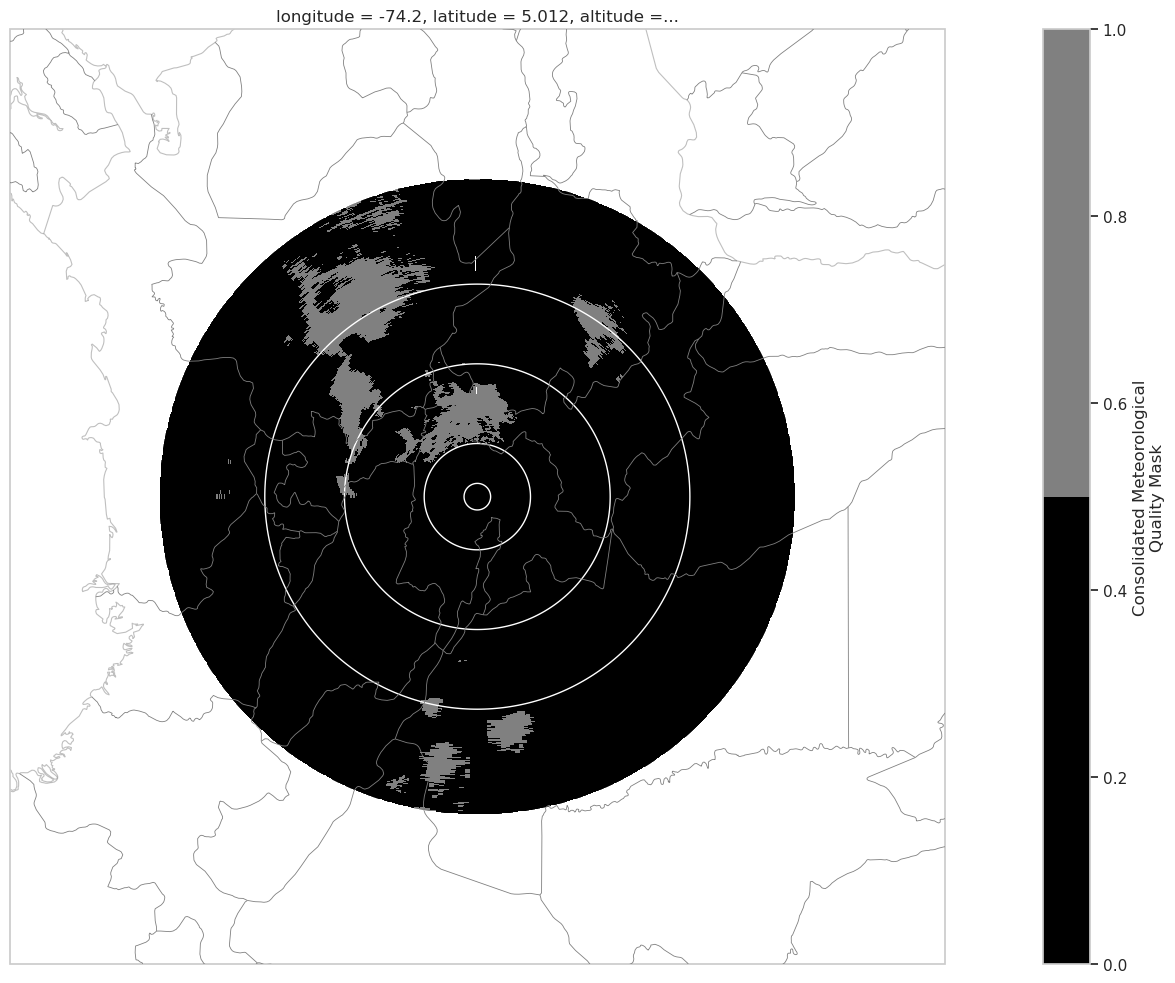

In [194]:
import matplotlib.colors as clr
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da.coords["longitude"] = dtree["longitude"].values
da.coords["latitude"] = dtree["latitude"].values
da.coords["altitude"] = dtree["altitude"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    cmap=clr.ListedColormap(['black', 'grey']),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)

wrl.vis.plot_ppi_crosshair(
    site=site,
    ranges=[12500,50000,125000,200000,300000,400000],
    line={"color": "None"},
    circle={"edgecolor": "white", "linewidth" : 1, "linestyle" : "-"},
    ax=ax,
    crs=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
)

plt.tight_layout()
plt.show()

In [195]:
var = "CBB"
ranges = [50000, 100000, 175000, 300000]

<xarray.DataArray 'CBB' (azimuth: 354, range: 664)> Size: 2MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(354, 664))
Coordinates:
  * azimuth         (azimuth) float32 1kB 0.04944 1.019 2.068 ... 358.1 359.0
    elevation       (azimuth) float64 3kB 0.4834 0.4834 0.4834 ... 0.4834 0.4834
    time            (azimuth) datetime64[ns] 3kB 2025-05-01T01:20:52.740000 ....
  * range           (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
    gate_latitude   (azimuth, range) float64 2MB 5.015 5.019 ... 7.705 7.709
    gate_longitude  (azimuth, range) float64 2MB -74.2 -74.2 ... -74.25 -74.25
    gate_height     (azimuth, range) float64 2MB 3.547e+03 3.55e+03 ... 1.13e+04
Attributes:
    long_name:  Cumulative Beam Blockage Fraction
    units:      1
    comment:    Calculat mitjança

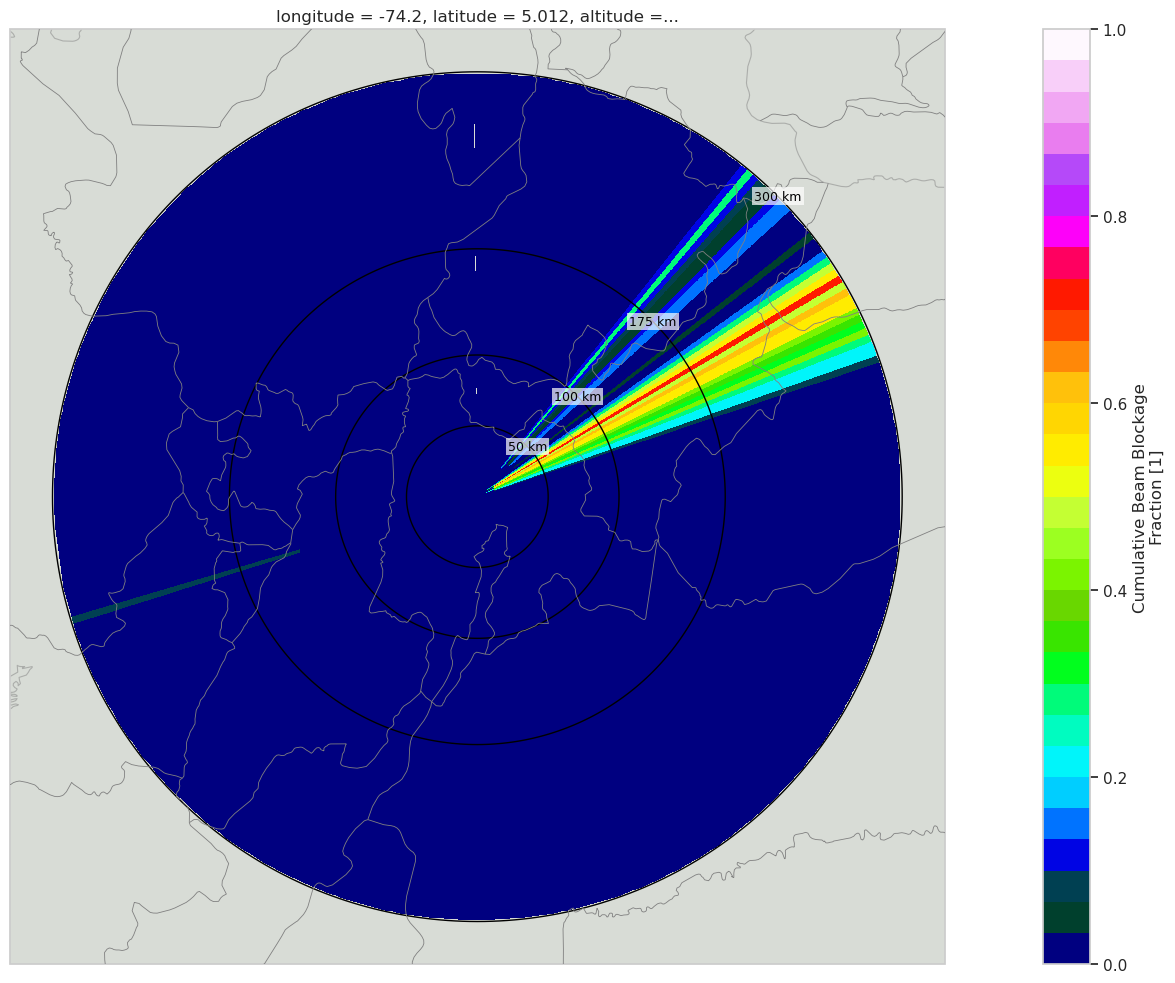

In [196]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da.coords["longitude"] = dtree["longitude"].values
da.coords["latitude"] = dtree["latitude"].values
da.coords["altitude"] = dtree["altitude"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

#fig.patch.set_facecolor('xkcd:light gray')
ax.set_facecolor('xkcd:light gray')   

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=1,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)
proj_crs = ccrs.AzimuthalEquidistant(
    central_longitude=da.longitude.values, 
    central_latitude=da.latitude.values
)

# 2. Your existing wradlib call
wrl.vis.plot_ppi_crosshair(
    site=site,
    ranges=ranges,
    line={"color": "None"},
    circle={"edgecolor": "black", "linewidth" : 1, "linestyle" : "-"},
    ax=ax,
    crs=proj_crs,
)

# 3. Add the text labels
# Choose an angle to place the text (e.g., 45 degrees, top-right quadrant)
angle_deg = 45 
angle_rad = np.radians(angle_deg)

for r in ranges:
    # Calculate x and y coordinates in meters from the center
    # In meteorology, 0 degrees is usually North. 
    # So x = r * sin(angle), y = r * cos(angle)
    x = r * np.sin(angle_rad)
    y = r * np.cos(angle_rad)
    
    # Format the label to km for readability (e.g., "12.5 km")
    label_text = f"{r / 1000:g} km"
    
    # Plot the text
    ax.text(
        x, y, label_text,
        transform=proj_crs,         # Ensures it maps to your cartopy projection correctly
        fontsize=9,
        ha='center',                # Horizontally center the text on the coordinate
        va='center',                # Vertically center the text on the coordinate
        color='black',
        # Adding a small, semi-transparent white box behind the text makes it 
        # readable even if it overlaps with intense radar echoes.
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5) 
    )

plt.tight_layout()

In [197]:
var = "DR"
ranges = [50000, 100000, 175000, 300000]

<xarray.DataArray 'DR' (azimuth: 354, range: 664)> Size: 2MB
array([[-2.87274268, -2.63692729, -2.21400862, ...,         nan,
                nan,         nan],
       [-3.5365707 , -2.31708575, -1.91689478, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       ...,
       [-4.36112402, -3.38498557,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ..., -7.32042587,
                nan,         nan],
       [-4.11057716, -0.84627758,         nan, ...,         nan,
                nan,         nan]], shape=(354, 664))
Coordinates:
  * azimuth         (azimuth) float32 1kB 0.04944 1.019 2.068 ... 358.1 359.0
    elevation       (azimuth) float64 3kB 0.4834 0.4834 0.4834 ... 0.4834 0.4834
    time            (azimuth) datetime64[ns] 3kB 2025-05-01T01:20:52.740000 ....
  * range           (range) float32 3kB 300.0 750.0 ...

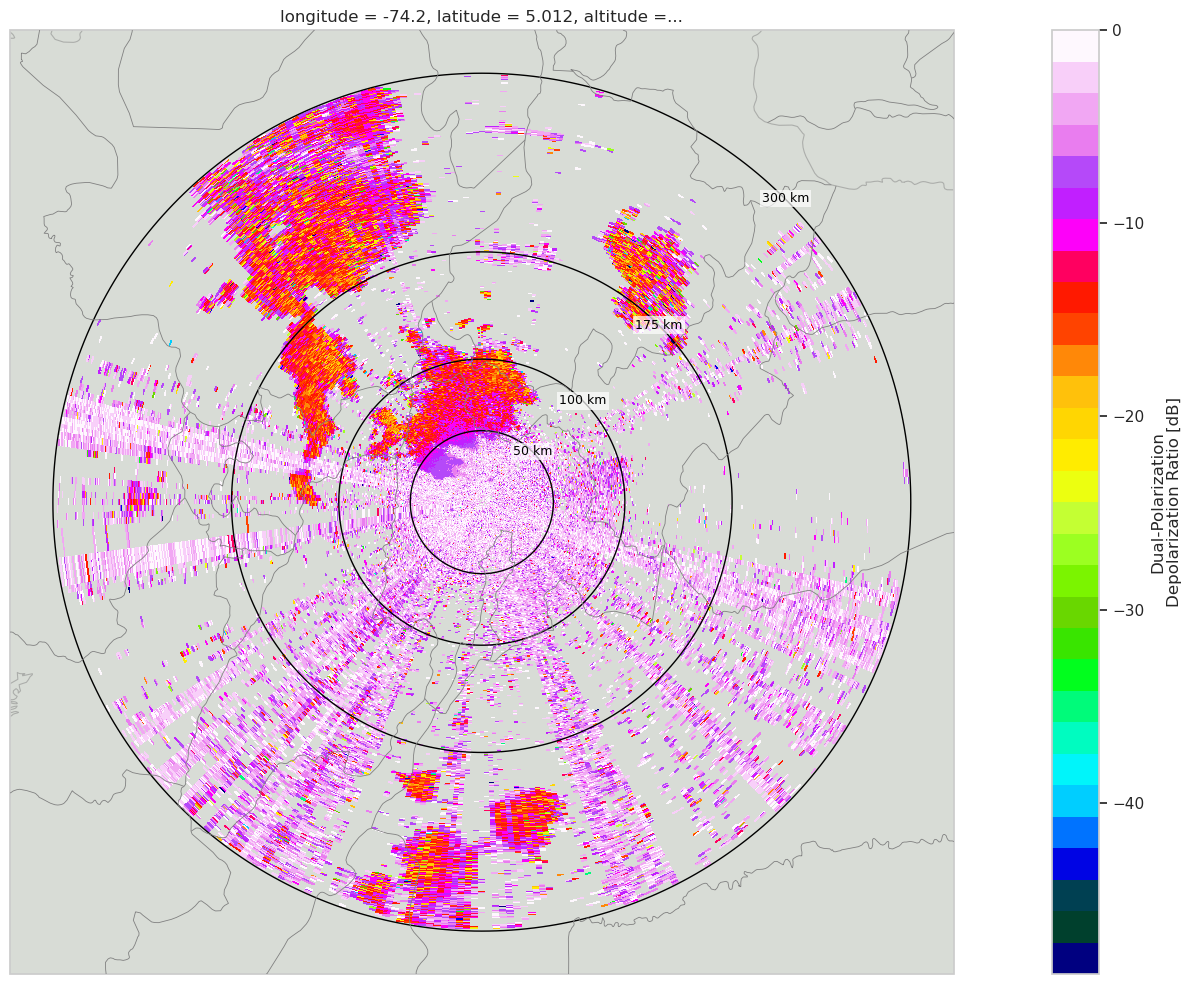

In [198]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da.coords["longitude"] = dtree["longitude"].values
da.coords["latitude"] = dtree["latitude"].values
da.coords["altitude"] = dtree["altitude"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

ax.set_facecolor('xkcd:light gray')   

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmax=0,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)

proj_crs = ccrs.AzimuthalEquidistant(
    central_longitude=da.longitude.values, 
    central_latitude=da.latitude.values
)

# 2. Your existing wradlib call
wrl.vis.plot_ppi_crosshair(
    site=site,
    ranges=ranges,
    line={"color": "None"},
    circle={"edgecolor": "black", "linewidth" : 1, "linestyle" : "-"},
    ax=ax,
    crs=proj_crs,
)

# 3. Add the text labels
# Choose an angle to place the text (e.g., 45 degrees, top-right quadrant)
angle_deg = 45 
angle_rad = np.radians(angle_deg)

for r in ranges:
    # Calculate x and y coordinates in meters from the center
    # In meteorology, 0 degrees is usually North. 
    # So x = r * sin(angle), y = r * cos(angle)
    x = r * np.sin(angle_rad)
    y = r * np.cos(angle_rad)
    
    # Format the label to km for readability (e.g., "12.5 km")
    label_text = f"{r / 1000:g} km"
    
    # Plot the text
    ax.text(
        x, y, label_text,
        transform=proj_crs,         # Ensures it maps to your cartopy projection correctly
        fontsize=9,
        ha='center',                # Horizontally center the text on the coordinate
        va='center',                # Vertically center the text on the coordinate
        color='black',
        # Adding a small, semi-transparent white box behind the text makes it 
        # readable even if it overlaps with intense radar echoes.
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5) 
    )

plt.tight_layout()
plt.show()

In [199]:
var1 = "KDP"
var2 = "cKDP"
var3 = "dKDP"

ranges = [50000, 100000, 175000, 300000]

<xarray.DataArray 'KDP' (azimuth: 354, range: 664)> Size: 940kB
[235056 values with dtype=float32]
Coordinates:
  * azimuth         (azimuth) float32 1kB 0.04944 1.019 2.068 ... 358.1 359.0
    elevation       (azimuth) float64 3kB 0.4834 0.4834 0.4834 ... 0.4834 0.4834
    time            (azimuth) datetime64[ns] 3kB 2025-05-01T01:20:52.740000 ....
  * range           (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
    gate_latitude   (azimuth, range) float64 2MB 5.015 5.019 ... 7.705 7.709
    gate_longitude  (azimuth, range) float64 2MB -74.2 -74.2 ... -74.25 -74.25
    gate_height     (azimuth, range) float64 2MB 3.547e+03 3.55e+03 ... 1.13e+04
Attributes:
    units:          degrees per kilometer
    standard_name:  radar_specific_differential_phase_hv
    long_name:      Specific differential phase HV
[-1.09204266 -1.0379843  -0.98660194 -0.93776312 -0.89134191 -0.84721865
 -0.80527958 -0.76541659 -0.72752689 -0.69151281 -0.6572815  -0.62474472
 -0.59381857 -0.56442332 -0

/tmp/ipykernel_12806/3864814399.py:213: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


[]

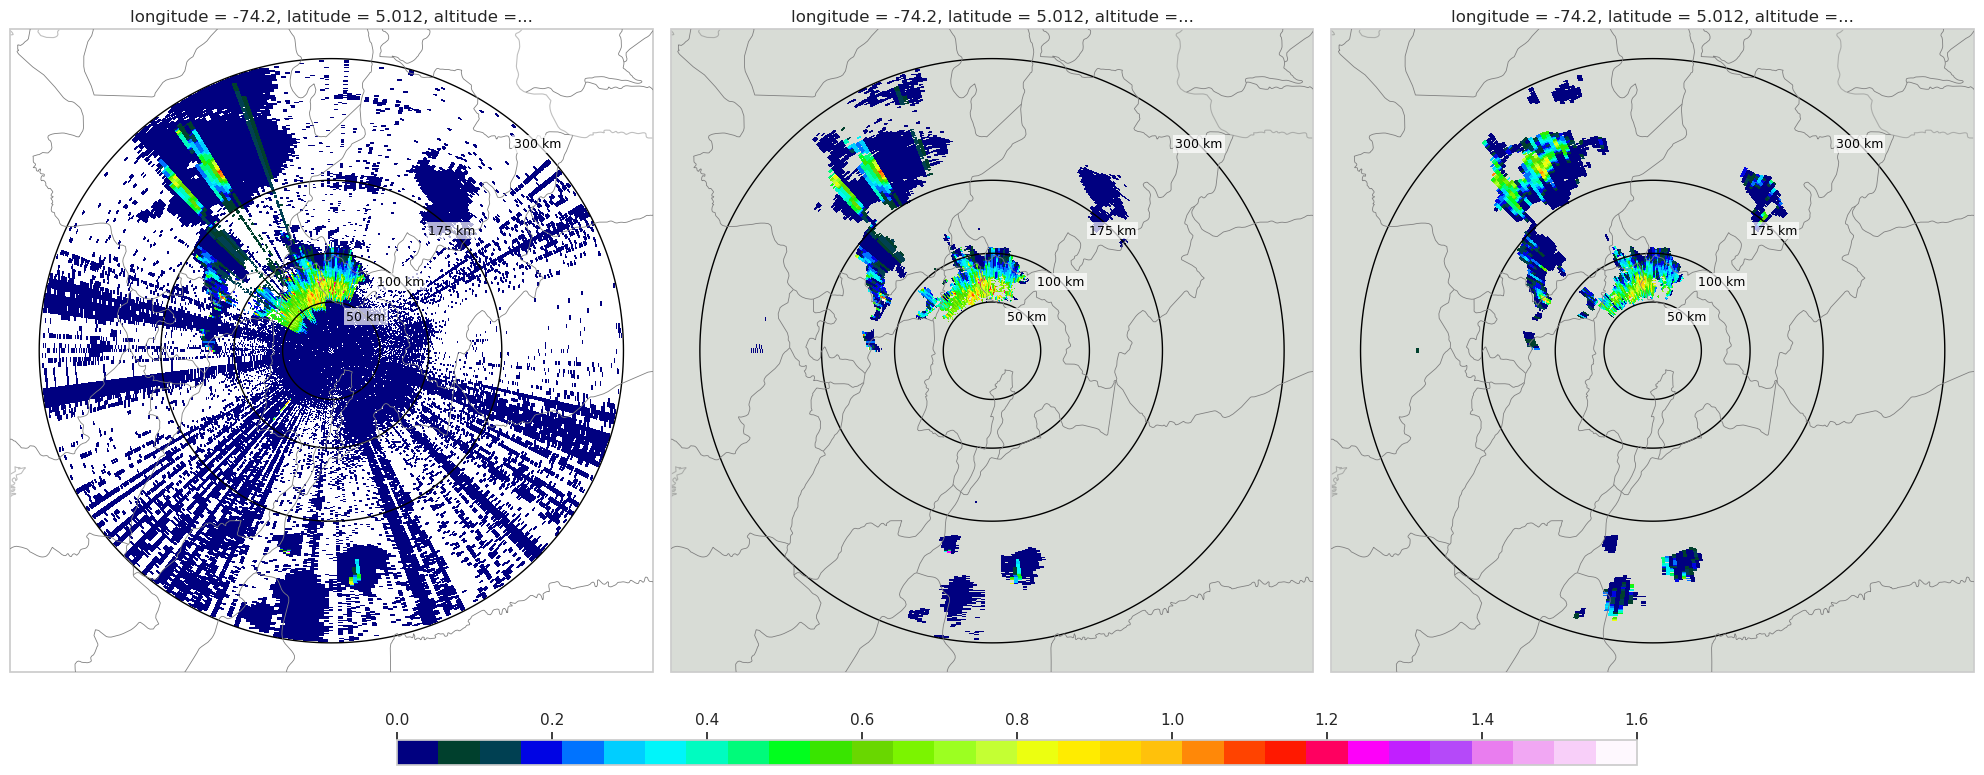

In [200]:
da1 = swp[f"{var1}"]

print(da1)
print(np.unique_values(da1.values[~np.isnan(da1.values)]))

da1.attrs["sweep_mode"] = swp["sweep_mode"].values
da1.coords["longitude"] = dtree["longitude"].values
da1.coords["latitude"] = dtree["latitude"].values
da1.coords["altitude"] = dtree["altitude"].values
da1_geo = da1.wrl.georef.georeference()
fig = plt.figure(figsize=(20,32))       
ax1 = fig.add_subplot(131, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))  

plot_features(ax1)
da1_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax1,
    vmin=0,
    vmax=1.6,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=False,
)

# 1. Define your parameters
proj_crs = ccrs.AzimuthalEquidistant(
    central_longitude=da.longitude.values, 
    central_latitude=da.latitude.values
)

# 2. Your existing wradlib call
wrl.vis.plot_ppi_crosshair(
    site=site,
    ranges=ranges,
    line={"color": "None"},
    circle={"edgecolor": "black", "linewidth" : 1, "linestyle" : "-"},
    ax=ax1,
    crs=proj_crs,
)

# 3. Add the text labels
# Choose an angle to place the text (e.g., 45 degrees, top-right quadrant)
angle_deg = 45 
angle_rad = np.radians(angle_deg)

for r in ranges:
    # Calculate x and y coordinates in meters from the center
    # In meteorology, 0 degrees is usually North. 
    # So x = r * sin(angle), y = r * cos(angle)
    x = r * np.sin(angle_rad)
    y = r * np.cos(angle_rad)
    
    # Format the label to km for readability (e.g., "12.5 km")
    label_text = f"{r / 1000:g} km"
    
    # Plot the text
    ax1.text(
        x, y, label_text,
        transform=proj_crs,         # Ensures it maps to your cartopy projection correctly
        fontsize=9,
        ha='center',                # Horizontally center the text on the coordinate
        va='center',                # Vertically center the text on the coordinate
        color='black',
        # Adding a small, semi-transparent white box behind the text makes it 
        # readable even if it overlaps with intense radar echoes.
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5) 
    )

da2 = swp[f"{var2}"]

print(da2)
print(np.unique_values(da2.values[~np.isnan(da2.values)]))

da2.attrs["sweep_mode"] = swp["sweep_mode"].values
da2.coords["longitude"] = dtree["longitude"].values
da2.coords["latitude"] = dtree["latitude"].values
da2.coords["altitude"] = dtree["altitude"].values
da2_geo = da2.wrl.georef.georeference()   
ax2 = fig.add_subplot(132, projection=ccrs.AzimuthalEquidistant(central_longitude=da1.longitude.values, central_latitude=da1.latitude.values))

ax2.set_facecolor('xkcd:light gray')   

plot_features(ax2)
cm2 = da2_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax2,
    vmin=0,
    vmax=1.6,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da2.longitude.values, central_latitude=da2.latitude.values),
    add_colorbar=False,
)

proj_crs = ccrs.AzimuthalEquidistant(
    central_longitude=da2.longitude.values, 
    central_latitude=da2.latitude.values
)

# 2. Your existing wradlib call
wrl.vis.plot_ppi_crosshair(
    site=site,
    ranges=ranges,
    line={"color": "None"},
    circle={"edgecolor": "black", "linewidth" : 1, "linestyle" : "-"},
    ax=ax2,
    crs=proj_crs,
)

# 3. Add the text labels
# Choose an angle to place the text (e.g., 45 degrees, top-right quadrant)
angle_deg = 45 
angle_rad = np.radians(angle_deg)

for r in ranges:
    # Calculate x and y coordinates in meters from the center
    # In meteorology, 0 degrees is usually North. 
    # So x = r * sin(angle), y = r * cos(angle)
    x = r * np.sin(angle_rad)
    y = r * np.cos(angle_rad)
    
    # Format the label to km for readability (e.g., "12.5 km")
    label_text = f"{r / 1000:g} km"
    
    # Plot the text
    ax2.text(
        x, y, label_text,
        transform=proj_crs,         # Ensures it maps to your cartopy projection correctly
        fontsize=9,
        ha='center',                # Horizontally center the text on the coordinate
        va='center',                # Vertically center the text on the coordinate
        color='black',
        # Adding a small, semi-transparent white box behind the text makes it 
        # readable even if it overlaps with intense radar echoes.
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5) 
    )

da3 = swp[f"{var3}"]

print(da3)
print(np.unique_values(da3.values[~np.isnan(da3.values)]))

da3.attrs["sweep_mode"] = swp["sweep_mode"].values
da3.coords["longitude"] = dtree["longitude"].values
da3.coords["latitude"] = dtree["latitude"].values
da3.coords["altitude"] = dtree["altitude"].values
da3_geo = da3.wrl.georef.georeference()   
ax3 = fig.add_subplot(133, projection=ccrs.AzimuthalEquidistant(central_longitude=da3.longitude.values, central_latitude=da3.latitude.values))

ax3.set_facecolor('xkcd:light gray')   

plot_features(ax3)

da3_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax3,
    vmin=0,
    vmax=1.6,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=False,
)

# 1. Define your parameters
proj_crs = ccrs.AzimuthalEquidistant(
    central_longitude=da.longitude.values, 
    central_latitude=da.latitude.values
)

# 2. Your existing wradlib call
wrl.vis.plot_ppi_crosshair(
    site=site,
    ranges=ranges,
    line={"color": "None"},
    circle={"edgecolor": "black", "linewidth" : 1, "linestyle" : "-"},
    ax=ax3,
    crs=proj_crs,
)

# 3. Add the text labels
# Choose an angle to place the text (e.g., 45 degrees, top-right quadrant)
angle_deg = 45 
angle_rad = np.radians(angle_deg)

for r in ranges:
    # Calculate x and y coordinates in meters from the center
    # In meteorology, 0 degrees is usually North. 
    # So x = r * sin(angle), y = r * cos(angle)
    x = r * np.sin(angle_rad)
    y = r * np.cos(angle_rad)
    
    # Format the label to km for readability (e.g., "12.5 km")
    label_text = f"{r / 1000:g} km"
    
    # Plot the text
    ax3.text(
        x, y, label_text,
        transform=proj_crs,         # Ensures it maps to your cartopy projection correctly
        fontsize=9,
        ha='center',                # Horizontally center the text on the coordinate
        va='center',                # Vertically center the text on the coordinate
        color='black',
        # Adding a small, semi-transparent white box behind the text makes it 
        # readable even if it overlaps with intense radar echoes.
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5) 
    )

fig.colorbar(cm2,ax=[ax1,ax2,ax3],orientation="horizontal", shrink=0.8, aspect=50,location="top")


plt.tight_layout()
plt.plot()

In [201]:
var = "RHOHV"
ranges = [50000, 100000, 175000, 300000]

<xarray.DataArray 'RHOHV' (azimuth: 354, range: 664)> Size: 940kB
[235056 values with dtype=float32]
Coordinates:
  * azimuth         (azimuth) float32 1kB 0.04944 1.019 2.068 ... 358.1 359.0
    elevation       (azimuth) float64 3kB 0.4834 0.4834 0.4834 ... 0.4834 0.4834
    time            (azimuth) datetime64[ns] 3kB 2025-05-01T01:20:52.740000 ....
  * range           (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
    gate_latitude   (azimuth, range) float64 2MB 5.015 5.019 ... 7.705 7.709
    gate_longitude  (azimuth, range) float64 2MB -74.2 -74.2 ... -74.25 -74.25
    gate_height     (azimuth, range) float64 2MB 3.547e+03 3.55e+03 ... 1.13e+04
Attributes:
    units:          unitless
    standard_name:  radar_correlation_coefficient_hv
    long_name:      Correlation coefficient HV
0.0
0.6286946134619315
0.889108448948774


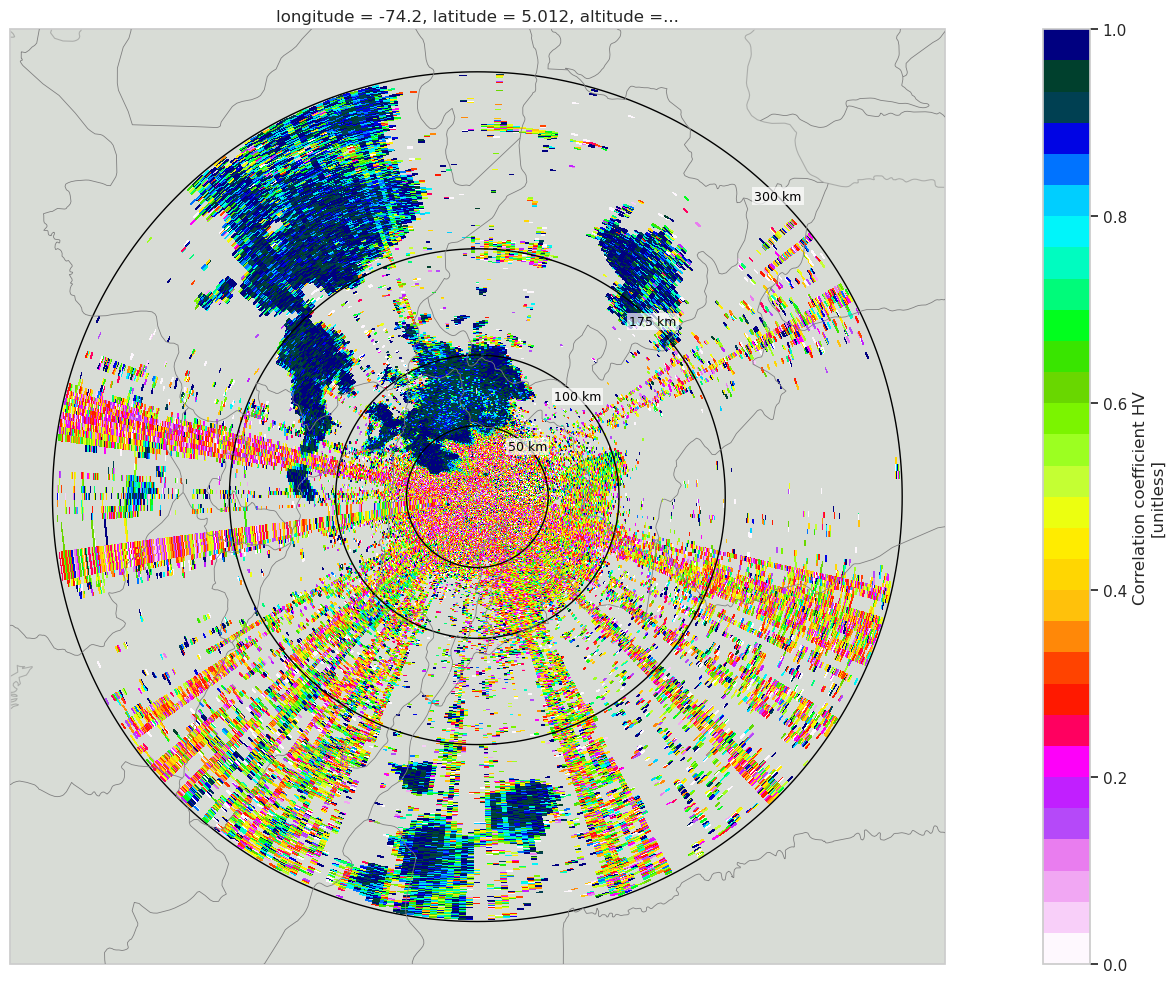

In [202]:
da = swp[f"{var}"]

print(da)
for value in np.unique_values(da.values[~np.isnan(da.values)])[::100]:
    print(value)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da.coords["longitude"] = dtree["longitude"].values
da.coords["latitude"] = dtree["latitude"].values
da.coords["altitude"] = dtree["altitude"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

ax.set_facecolor('xkcd:light gray') 

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    cmap=cmap.Colormap("ncar_r").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)

proj_crs = ccrs.AzimuthalEquidistant(
    central_longitude=da.longitude.values, 
    central_latitude=da.latitude.values
)

# 2. Your existing wradlib call
wrl.vis.plot_ppi_crosshair(
    site=site,
    ranges=ranges,
    line={"color": "None"},
    circle={"edgecolor": "black", "linewidth" : 1, "linestyle" : "-"},
    ax=ax,
    crs=proj_crs,
)

# 3. Add the text labels
# Choose an angle to place the text (e.g., 45 degrees, top-right quadrant)
angle_deg = 45 
angle_rad = np.radians(angle_deg)

for r in ranges:
    # Calculate x and y coordinates in meters from the center
    # In meteorology, 0 degrees is usually North. 
    # So x = r * sin(angle), y = r * cos(angle)
    x = r * np.sin(angle_rad)
    y = r * np.cos(angle_rad)
    
    # Format the label to km for readability (e.g., "12.5 km")
    label_text = f"{r / 1000:g} km"
    
    # Plot the text
    ax.text(
        x, y, label_text,
        transform=proj_crs,         # Ensures it maps to your cartopy projection correctly
        fontsize=9,
        ha='center',                # Horizontally center the text on the coordinate
        va='center',                # Vertically center the text on the coordinate
        color='black',
        # Adding a small, semi-transparent white box behind the text makes it 
        # readable even if it overlaps with intense radar echoes.
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5) 
    )

plt.tight_layout()

In [203]:
var = "R_A"
ranges = [50000,100000,175000,300000]

<xarray.DataArray 'R_A' (azimuth: 354, range: 664)> Size: 2MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(354, 664))
Coordinates:
  * azimuth         (azimuth) float32 1kB 0.04944 1.019 2.068 ... 358.1 359.0
    elevation       (azimuth) float64 3kB 0.4834 0.4834 0.4834 ... 0.4834 0.4834
    time            (azimuth) datetime64[ns] 3kB 2025-05-01T01:20:52.740000 ....
  * range           (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
    gate_latitude   (azimuth, range) float64 2MB 5.015 5.019 ... 7.705 7.709
    gate_longitude  (azimuth, range) float64 2MB -74.2 -74.2 ... -74.25 -74.25
    gate_height     (azimuth, range) float64 2MB 3.547e+03 3.55e+03 ... 1.13e+04
0.0
1.6337125642734301e-31
1.9203802386524952e-31
2.146257991031761e-31
2.422

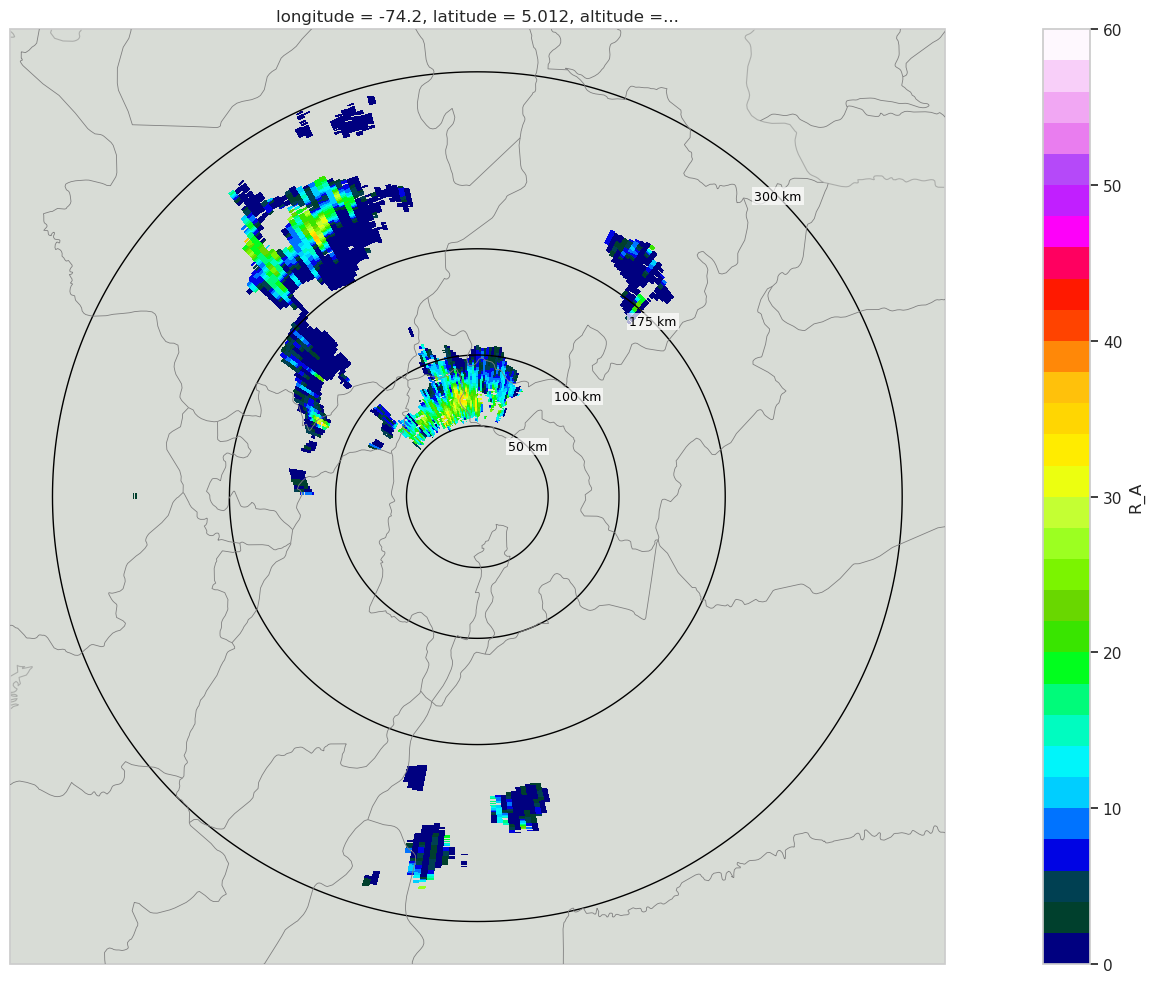

In [204]:
da = swp[f"{var}"]

print(da)
for value in np.unique_values(da.values[~np.isnan(da.values)]):
    print(value)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da.coords["longitude"] = dtree["longitude"].values
da.coords["latitude"] = dtree["latitude"].values
da.coords["altitude"] = dtree["altitude"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

ax.set_facecolor('xkcd:light gray') 

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=60,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)

proj_crs = ccrs.AzimuthalEquidistant(
    central_longitude=da.longitude.values, 
    central_latitude=da.latitude.values
)

# 2. Your existing wradlib call
wrl.vis.plot_ppi_crosshair(
    site=site,
    ranges=ranges,
    line={"color": "None"},
    circle={"edgecolor": "black", "linewidth" : 1, "linestyle" : "-"},
    ax=ax,
    crs=proj_crs,
)

# 3. Add the text labels
# Choose an angle to place the text (e.g., 45 degrees, top-right quadrant)
angle_deg = 45 
angle_rad = np.radians(angle_deg)

for r in ranges:
    # Calculate x and y coordinates in meters from the center
    # In meteorology, 0 degrees is usually North. 
    # So x = r * sin(angle), y = r * cos(angle)
    x = r * np.sin(angle_rad)
    y = r * np.cos(angle_rad)
    
    # Format the label to km for readability (e.g., "12.5 km")
    label_text = f"{r / 1000:g} km"
    
    # Plot the text
    ax.text(
        x, y, label_text,
        transform=proj_crs,         # Ensures it maps to your cartopy projection correctly
        fontsize=9,
        ha='center',                # Horizontally center the text on the coordinate
        va='center',                # Vertically center the text on the coordinate
        color='black',
        # Adding a small, semi-transparent white box behind the text makes it 
        # readable even if it overlaps with intense radar echoes.
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5) 
    )


plt.tight_layout()

In [205]:
var= "R_KDP"

<xarray.DataArray 'R_KDP' (azimuth: 354, range: 664)> Size: 2MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(354, 664))
Coordinates:
  * azimuth         (azimuth) float32 1kB 0.04944 1.019 2.068 ... 358.1 359.0
    elevation       (azimuth) float64 3kB 0.4834 0.4834 0.4834 ... 0.4834 0.4834
    time            (azimuth) datetime64[ns] 3kB 2025-05-01T01:20:52.740000 ....
  * range           (range) float32 3kB 300.0 750.0 ... 2.982e+05 2.986e+05
    gate_latitude   (azimuth, range) float64 2MB 5.015 5.019 ... 7.705 7.709
    gate_longitude  (azimuth, range) float64 2MB -74.2 -74.2 ... -74.25 -74.25
    gate_height     (azimuth, range) float64 2MB 3.547e+03 3.55e+03 ... 1.13e+04
0.0
9.867702296052044e-24
1.1152852853972916e-23
1.2132733420153649e-23
1.3

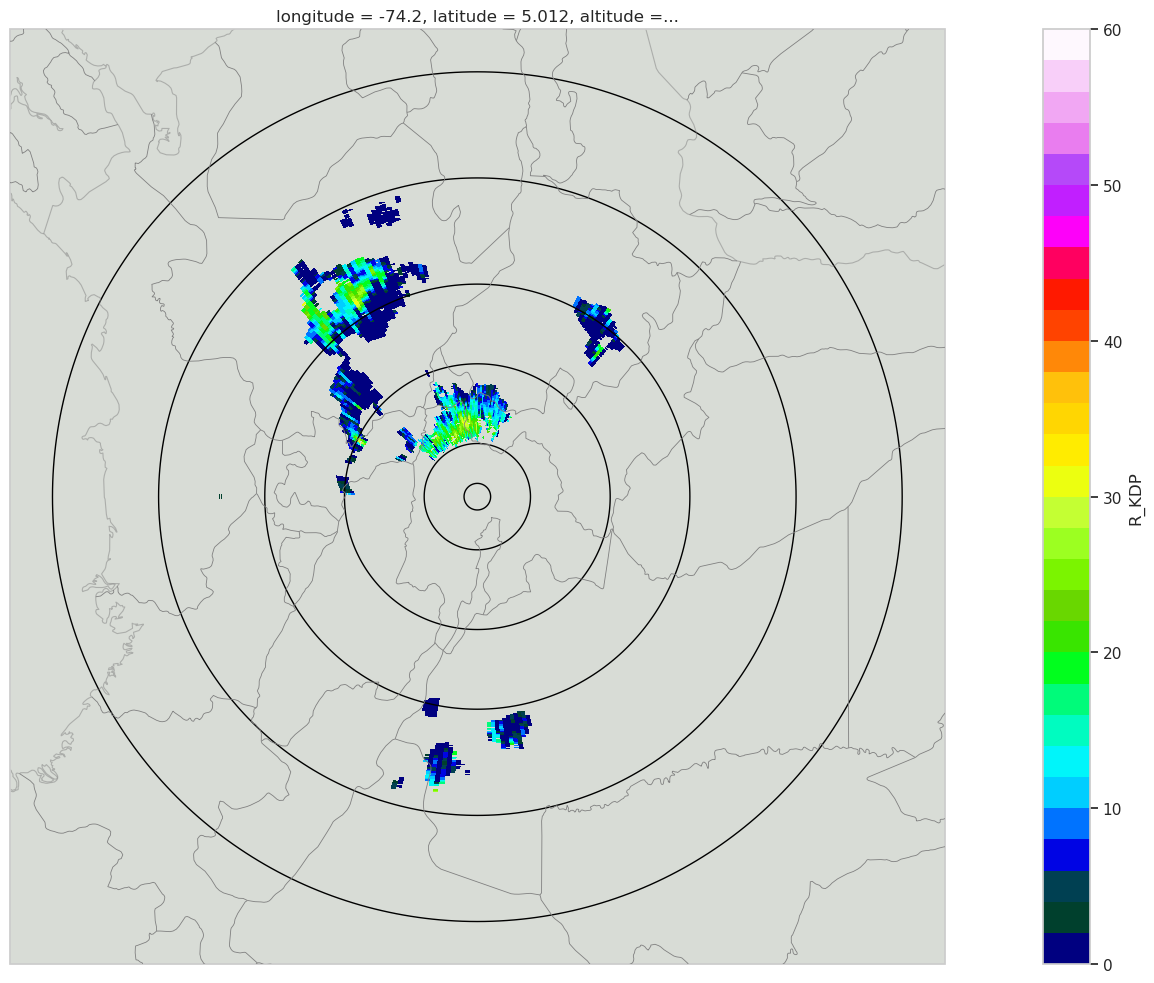

In [206]:
da = swp[f"{var}"]

print(da)
for value in np.unique_values(da.values[~np.isnan(da.values)]):
    print(value)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da.coords["longitude"] = dtree["longitude"].values
da.coords["latitude"] = dtree["latitude"].values
da.coords["altitude"] = dtree["altitude"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

ax.set_facecolor('xkcd:light gray') 

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=60,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=True,
)

wrl.vis.plot_ppi_crosshair(
    site=site,
    ranges=[12500,50000,125000,200000,300000,400000],
    line={"color": "None"},
    circle={"edgecolor": "black", "linewidth" : 1, "linestyle" : "-"},
    ax=ax,
    crs=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
)

plt.tight_layout()

In [129]:
lat = dtree.latitude.values
lon = dtree.longitude.values
max_range = swp.range.values[-1]/1e3/111

max_lat = lat + max_range
max_lon = lon + max_range
min_lat = lat - max_range
min_lon = lon - max_range

In [130]:
from sodapy import Socrata
import datetime as dt
import pandas as pd

TOKEN = "MFHXNYLts4ZhySVUsR7emeZXO"

def download_data(date_init: dt.datetime, date_end: dt.datetime) -> pd.DataFrame:
    client = Socrata("www.datos.gov.co", TOKEN)

    date_init = pd.Timestamp(date_init).tz_localize('UTC').tz_convert('America/Bogota')
    date_end  = pd.Timestamp(date_end).tz_localize('UTC').tz_convert('America/Bogota')
    #print(date_end)

    query = client.get(
        dataset_identifier = "s54a-sgyg",
        select             = "codigoestacion, fechaobservacion, latitud, longitud, valorobservado, unidadmedida",
        where              = f"fechaobservacion >= '{date_init.strftime('%Y-%m-%d')}' AND fechaobservacion <= '{date_end.strftime('%Y-%m-%d')}'"
                             f"AND latitud > '{min_lat}' AND latitud < '{max_lat}' AND longitud > '{min_lon}' AND longitud < '{max_lon}'",
        limit              = 50000000,
    )

    data = pd.DataFrame.from_records(query)

    return data

In [140]:
time_str = dtree["time_coverage_start"].values
#time_str = time_arr.item().decode('utf-8')
time_pd = pd.to_datetime(time_str)
print(time_pd)  

start_utc = time_pd - pd.Timedelta(minutes=9)
end_utc   = time_pd + pd.Timedelta(minutes=1)
#print(start_utc)
#print(end_utc)
start = dt.datetime(2025,5,3)#dt.datetime(time_pd.year,time_pd.month,time_pd.day)
print("start:", start)
end = dt.datetime(2025,5,4)#dt.datetime(time_pd.year,time_pd.month,time_pd.day +15)
print("end:", end)

df = download_data(start,end) # a dia 12/05/2026 no funciona del tot correctament i has de posar un dia més perquè et retorni el dia que pertoca
print(df)

2025-05-02 06:59:21+00:00
start: 2025-05-03 00:00:00
end: 2025-05-04 00:00:00
      codigoestacion         fechaobservacion      latitud       longitud  \
0         0023017040  2025-05-02T00:00:00.000     5.203718     -74.908378   
1         2120000139  2025-05-02T00:00:00.000      4.67553      -74.01927   
2         2120000100  2025-05-02T00:00:00.000     4.652389     -74.075434   
3         2120000135  2025-05-02T00:00:00.000      4.61823      -74.06439   
4         2120700154  2025-05-02T00:00:00.000      4.55322      -74.10789   
...              ...                      ...          ...            ...   
73822     0021115100  2025-05-03T00:00:00.000  2.942638889   -75.06638889   
73823     2120000135  2025-05-03T00:00:00.000      4.61823      -74.06439   
73824     2120000175  2025-05-03T00:00:00.000        4.656  -74.131111111   
73825     0021201580  2025-05-03T00:00:00.000   4.44647201     -74.154839   
73826     2120000173  2025-05-03T00:00:00.000      4.67168      -74.15894  

In [141]:
print(np.unique_counts(df["valorobservado"]))

df["fechaobservacion"] = (
    pd.to_datetime(df["fechaobservacion"])
    .dt.tz_localize("America/Bogota")
    .dt.tz_convert("UTC")
)
print(df)

UniqueCountsResult(values=array(['0', '0.001', '0.002', '0.006', '0.007', '0.01', '0.013', '0.032',
       '0.041', '0.074', '0.1', '0.103', '0.114', '0.116', '0.2', '0.249',
       '0.3', '0.361', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '1',
       '1.1', '1.2', '1.3', '1.4', '1.5', '1.6', '1.7', '1.8', '1.9',
       '10.1', '10.2', '10.4', '12.6', '13', '2', '2.1', '2.2', '2.4',
       '2.6', '2.7', '2.8', '24.3', '3', '3.4', '3.6', '4', '4.2', '4.4',
       '4.6', '5.2', '5.5', '5.7', '5.8', '6.2', '6.4', '6.8', '6.9', '7',
       '7.2', '7.3', '7.4', '7.8', '8', '9.6'], dtype=object), counts=array([71241,     1,     2,     1,     1,     1,     1,     1,     1,
           1,  1778,     1,     1,     1,   393,     1,   118,     1,
          64,    38,    32,    15,    16,    12,    14,     3,     3,
           1,     4,     1,     4,     1,     3,     2,     1,     1,
           1,     1,     1,     6,     3,     2,     1,     1,     1,
           5,     1,    11,     1,     2,    

In [142]:
df["valorobservado"] = pd.to_numeric(df["valorobservado"], errors="coerce")
df = df.dropna(subset=["valorobservado"])

df["latitud"] = pd.to_numeric(df["latitud"], errors="coerce")
df =df.dropna(subset=["latitud"])

df["longitud"] = pd.to_numeric(df["longitud"], errors="coerce")
df = df.dropna(subset=["longitud"])

print(df)

      codigoestacion          fechaobservacion   latitud   longitud  \
0         0023017040 2025-05-02 05:00:00+00:00  5.203718 -74.908378   
1         2120000139 2025-05-02 05:00:00+00:00  4.675530 -74.019270   
2         2120000100 2025-05-02 05:00:00+00:00  4.652389 -74.075434   
3         2120000135 2025-05-02 05:00:00+00:00  4.618230 -74.064390   
4         2120700154 2025-05-02 05:00:00+00:00  4.553220 -74.107890   
...              ...                       ...       ...        ...   
73822     0021115100 2025-05-03 05:00:00+00:00  2.942639 -75.066389   
73823     2120000135 2025-05-03 05:00:00+00:00  4.618230 -74.064390   
73824     2120000175 2025-05-03 05:00:00+00:00  4.656000 -74.131111   
73825     0021201580 2025-05-03 05:00:00+00:00  4.446472 -74.154839   
73826     2120000173 2025-05-03 05:00:00+00:00  4.671680 -74.158940   

       valorobservado unidadmedida  
0                 0.0           mm  
1                 0.0           mm  
2                 0.0           mm  

In [143]:
utc_start = start_utc.normalize()+ pd.Timedelta(days=1)
utc_end = utc_start + pd.Timedelta(days=2) #se'ls hi ha de sumar perquè sempre tinc -1 dia
print(utc_start)
print(utc_end)
print(start_utc)

date_filtered_df = df[df["fechaobservacion"].between(utc_start, utc_end)]

#for fecha in date_filtered_df["fechaobservacion"].values:
#    print(fecha)
print(date_filtered_df)

time_utc_start = pd.Timestamp(f"{start_utc.hour}:{start_utc.minute}:00", tz="UTC").time()
time_utc_end   = pd.Timestamp(f"{end_utc.hour}:{end_utc.minute}:00", tz="UTC").time()
time_filtered_df = date_filtered_df[date_filtered_df["fechaobservacion"].dt.time.between(time_utc_start, time_utc_end)]

print(time_filtered_df)

2025-05-03 00:00:00+00:00
2025-05-05 00:00:00+00:00
2025-05-02 06:50:21+00:00
      codigoestacion          fechaobservacion   latitud   longitud  \
58057     0021217180 2025-05-03 00:00:00+00:00  4.481944 -75.286111   
58058     0021205660 2025-05-03 00:00:00+00:00  4.579100 -74.523180   
58059     0021195120 2025-05-03 00:00:00+00:00  4.392920 -74.392720   
58060     0035017020 2025-05-03 00:00:00+00:00  4.103019 -72.936383   
58061     2120000174 2025-05-03 00:00:00+00:00  4.686640 -74.082960   
...              ...                       ...       ...        ...   
73822     0021115100 2025-05-03 05:00:00+00:00  2.942639 -75.066389   
73823     2120000135 2025-05-03 05:00:00+00:00  4.618230 -74.064390   
73824     2120000175 2025-05-03 05:00:00+00:00  4.656000 -74.131111   
73825     0021201580 2025-05-03 05:00:00+00:00  4.446472 -74.154839   
73826     2120000173 2025-05-03 05:00:00+00:00  4.671680 -74.158940   

       valorobservado unidadmedida  
58057             0.0           

In [144]:
filtered_df = date_filtered_df

In [145]:
print(np.unique_counts(filtered_df["codigoestacion"]))

UniqueCountsResult(values=array(['0021115100', '0021130050', '0021135020', '0021140120',
       '0021185030', '0021185080', '0021185090', '0021195120',
       '0021201200', '0021201580', '0021201980', '0021202180',
       '0021202190', '0021202220', '0021202230', '0021202240',
       '0021202250', '0021205012', '0021205420', '0021205660',
       '0021205670', '0021205710', '0021205791', '0021205910',
       '0021205940', '0021205970', '0021206280', '0021206560',
       '0021206600', '0021206780', '0021206810', '0021206890',
       '0021206900', '0021208480', '0021209920', '0021215160',
       '0021217180', '0021227010', '0021235030', '0021245140',
       '0021255090', '0021255170', '0021257100', '0023017040',
       '0023065120', '0023067050', '0032105080', '0033035010',
       '0034015010', '0035017020', '0035020300', '0035025060',
       '0035025080', '0035027001', '0035035100', '0035035110',
       '0035035130', '0035060210', '0035087020', '0035195020',
       '0035197030', '0035225

In [146]:
filtered_df["valorobservado"] = pd.to_numeric(filtered_df["valorobservado"].astype(float)*6, errors="coerce")
filtered_df = filtered_df.dropna(subset=["valorobservado"])

filtered_df["latitud"] = pd.to_numeric(filtered_df["latitud"], errors="coerce")
filtered_df =filtered_df.dropna(subset=["latitud"])

filtered_df["longitud"] = pd.to_numeric(filtered_df["longitud"], errors="coerce")
filtered_df = filtered_df.dropna(subset=["longitud"])

print(filtered_df)

      codigoestacion          fechaobservacion   latitud   longitud  \
58057     0021217180 2025-05-03 00:00:00+00:00  4.481944 -75.286111   
58058     0021205660 2025-05-03 00:00:00+00:00  4.579100 -74.523180   
58059     0021195120 2025-05-03 00:00:00+00:00  4.392920 -74.392720   
58060     0035017020 2025-05-03 00:00:00+00:00  4.103019 -72.936383   
58061     2120000174 2025-05-03 00:00:00+00:00  4.686640 -74.082960   
...              ...                       ...       ...        ...   
73822     0021115100 2025-05-03 05:00:00+00:00  2.942639 -75.066389   
73823     2120000135 2025-05-03 05:00:00+00:00  4.618230 -74.064390   
73824     2120000175 2025-05-03 05:00:00+00:00  4.656000 -74.131111   
73825     0021201580 2025-05-03 05:00:00+00:00  4.446472 -74.154839   
73826     2120000173 2025-05-03 05:00:00+00:00  4.671680 -74.158940   

       valorobservado unidadmedida  
58057             0.0           mm  
58058             0.0           mm  
58059             0.0           mm  

/tmp/ipykernel_12806/1769763942.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["valorobservado"] = pd.to_numeric(filtered_df["valorobservado"].astype(float)*6, errors="coerce")


In [147]:
# 1. Assegura't que el format de temps és correcte
print(df['fechaobservacion'].dtype)

# 2. Inclou les coordenades al groupby perquè no s'eliminin
hourly_geo_df = df.groupby([
    'codigoestacion', 
    'latitud', 
    'longitud', 
    pd.Grouper(key='fechaobservacion', freq='h')
])['valorobservado'].sum().reset_index()

# 3. Redissenya el nom de la columna acumulada
hourly_geo_df = hourly_geo_df.rename(columns={'valorobservado': 'acumulado_horario'})

#print(hourly_geo_df[hourly_geo_df["codigoestacion"] == "0021015020"])

print(hourly_geo_df["fechaobservacion"])

datetime64[ns, UTC]
0      2025-05-02 05:00:00+00:00
1      2025-05-02 06:00:00+00:00
2      2025-05-02 07:00:00+00:00
3      2025-05-02 08:00:00+00:00
4      2025-05-02 09:00:00+00:00
                  ...           
2918   2025-05-03 01:00:00+00:00
2919   2025-05-03 02:00:00+00:00
2920   2025-05-03 03:00:00+00:00
2921   2025-05-03 04:00:00+00:00
2922   2025-05-03 05:00:00+00:00
Name: fechaobservacion, Length: 2923, dtype: datetime64[ns, UTC]


In [148]:
var="R_A"
number_of_colors=25
ranges = [50000, 100000,175000,300000]

<xarray.DataArray 'R_A' (azimuth: 720, range: 994)> Size: 6MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ...,  0.,  0.,  0.],
       [nan, nan, nan, ...,  0.,  0.,  0.],
       [nan, nan, nan, ...,  0.,  0.,  0.]], shape=(720, 994))
Coordinates:
  * azimuth         (azimuth) float32 3kB 0.02197 0.5191 1.022 ... 359.0 359.5
    elevation       (azimuth) float64 6kB 0.5164 0.5164 0.5164 ... 0.5164 0.5164
    time            (azimuth) datetime64[ns] 6kB 2025-05-02T06:59:37.601000 ....
  * range           (range) float32 4kB 1e+03 1.3e+03 ... 2.986e+05 2.989e+05
    gate_latitude   (azimuth, range) float64 6MB 2.543 2.546 ... 5.232 5.235
    gate_longitude  (azimuth, range) float64 6MB -72.63 -72.63 ... -72.65 -72.65
    gate_height     (azimuth, range) float64 6MB 249.1 251.8 ... 8.183e+03
Attributes:
    sweep_mode:  azimuth_surveillance
     codigoestacion   latitu

/tmp/ipykernel_12806/2281801769.py:55: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  zeros = hour_geo_df[hourly_geo_df["acumulado_horario"] == 0]
/tmp/ipykernel_12806/2281801769.py:56: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  nonzeros = hour_geo_df[hourly_geo_df["acumulado_horario"] > 0]


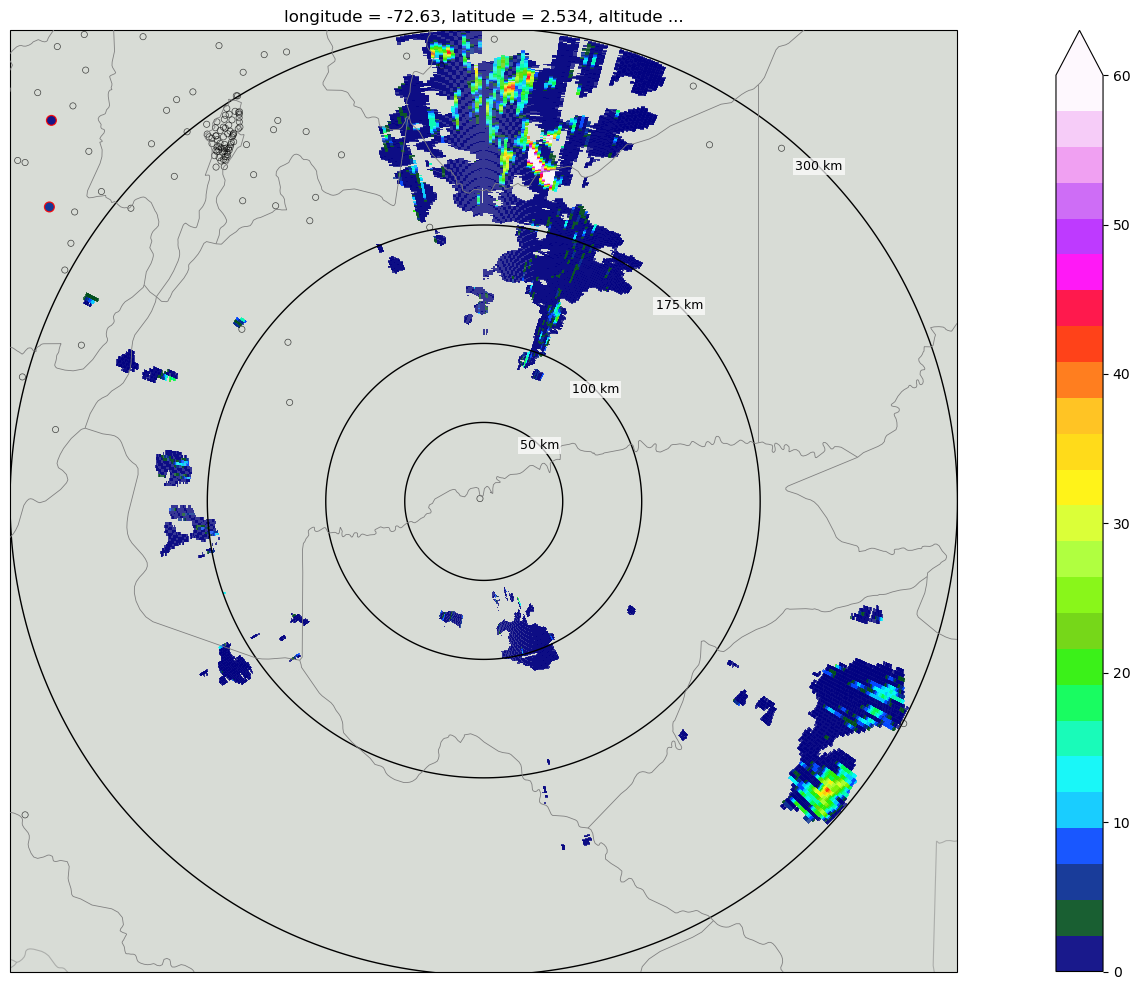

In [149]:
da = swp[f"{var}"]

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da.coords["longitude"] = dtree["longitude"].values
da.coords["latitude"] = dtree["latitude"].values
da.coords["altitude"] = dtree["altitude"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

ax.set_facecolor('xkcd:light gray') 

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=60,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=False,
    alpha=0.75
)

hourly_geo_df = hourly_geo_df.dropna(subset=["longitud", "latitud", "acumulado_horario"])

hora_a_plotejar = 6

hour_geo_df = hourly_geo_df[hourly_geo_df['fechaobservacion'].dt.hour == hora_a_plotejar].copy()

print(hour_geo_df)

print(f"Plotting {len(hour_geo_df)} points")
#print(f"Lon range: {hourly_geo_df['longitud'].min():.4f} to {hourly_geo_df['longitud'].max():.4f}")
#print(f"Lat range: {hourly_geo_df['latitud'].min():.4f} to {hourly_geo_df['latitud'].max():.4f}")

# ---- Center projection on the data ----
#center_lon = filtered_df["longitud"].mean()
#center_lat = filtered_df["latitud"].mean()

# ---- Map features ----
department_lines = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    edgecolor='black',
    facecolor='never',
    linewidth=0.6
)

# ---- Separar según valor observado ----
zeros = hour_geo_df[hourly_geo_df["acumulado_horario"] == 0]
nonzeros = hour_geo_df[hourly_geo_df["acumulado_horario"] > 0]
print(zeros)

# ---- Dibujar puntos con precipitación >0 (relleno con colormap) ----
sc = ax.scatter(
    nonzeros["longitud"],
    nonzeros["latitud"],
    c=nonzeros["acumulado_horario"],
    vmin=0,
    vmax=60,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    s=50,
    edgecolors="red",
    linewidth=0.9,
    alpha=0.9,
    transform=ccrs.PlateCarree(),
    zorder=1,
)

# ---- Dibujar puntos con valor == 0 (solo borde, sin relleno) ----
ax.scatter(
    zeros["longitud"],
    zeros["latitud"],
    facecolors="none",
    edgecolors="black",
    s=20,
    linewidth=0.5,
    alpha=0.7,
    transform=ccrs.PlateCarree(),
    zorder=2,
)

cb = plt.colorbar(sc,ax=ax,extend="max")

# ---- Adjust map extent to data bounds with a small margin ----
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

proj_crs = ccrs.AzimuthalEquidistant(
    central_longitude=da.longitude.values, 
    central_latitude=da.latitude.values
)

# 2. Your existing wradlib call
wrl.vis.plot_ppi_crosshair(
    site=site,
    ranges=ranges,
    line={"color": "None"},
    circle={"edgecolor": "black", "linewidth" : 1, "linestyle" : "-"},
    ax=ax,
    crs=proj_crs,
)

# 3. Add the text labels
# Choose an angle to place the text (e.g., 45 degrees, top-right quadrant)
angle_deg = 45 
angle_rad = np.radians(angle_deg)

for r in ranges:
    # Calculate x and y coordinates in meters from the center
    # In meteorology, 0 degrees is usually North. 
    # So x = r * sin(angle), y = r * cos(angle)
    x = r * np.sin(angle_rad)
    y = r * np.cos(angle_rad)
    
    # Format the label to km for readability (e.g., "12.5 km")
    label_text = f"{r / 1000:g} km"
    
    # Plot the text
    ax.text(
        x, y, label_text,
        transform=proj_crs,         # Ensures it maps to your cartopy projection correctly
        fontsize=9,
        ha='center',                # Horizontally center the text on the coordinate
        va='center',                # Vertically center the text on the coordinate
        color='black',
        # Adding a small, semi-transparent white box behind the text makes it 
        # readable even if it overlaps with intense radar echoes.
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5) 
    )

plt.tight_layout()
plt.show()

In [150]:
print(dtree.longitude)
print(dtree.latitude)
print(swp.range.values[1]-swp.range.values[0])

<xarray.DataArray 'longitude' ()> Size: 8B
array(-72.62847)
Coordinates:
    latitude   float64 8B 2.534
    longitude  float64 8B -72.63
    altitude   float64 8B 240.0
Attributes:
    long_name:      longitude
    units:          degrees_east
    standard_name:  longitude
<xarray.DataArray 'latitude' ()> Size: 8B
array(2.53375)
Coordinates:
    latitude   float64 8B 2.534
    longitude  float64 8B -72.63
    altitude   float64 8B 240.0
Attributes:
    long_name:      latitude
    units:          degrees_north
    positive:       up
    standard_name:  latitude
300.0


DataFrame global preparat:
  codigoestacion          fechaobservacion  radar_az_idx  radar_rng_idx  \
0     0021115100 2025-05-02 05:00:00+00:00           559            913   
1     0021115100 2025-05-02 06:00:00+00:00           559            913   
2     0021115100 2025-05-02 07:00:00+00:00           559            913   
3     0021115100 2025-05-02 08:00:00+00:00           559            913   
4     0021115100 2025-05-02 09:00:00+00:00           559            913   

   distance_to_radar_gate_m  
0                118.816352  
1                118.816352  
2                118.816352  
3                118.816352  
4                118.816352  
Valors únics del radar i les seves freqüències:
 {np.float64(0.0): np.int64(117)}


/tmp/ipykernel_12806/910058895.py:97: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left')


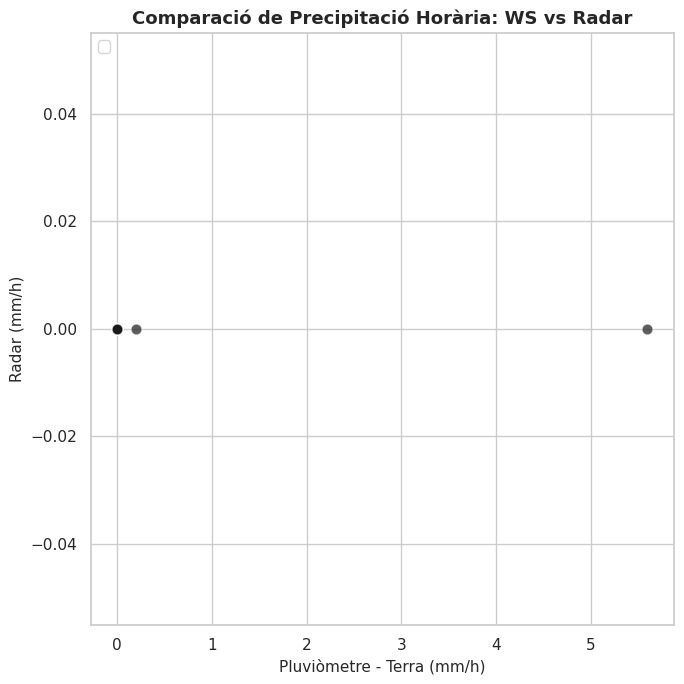

In [151]:
# ==========================================
# CÀLCULS PREVIS I CERCA GEOMÈTRICA (EL TEU CODI)
# ==========================================
gate_lon = swp["gate_longitude"].values
gate_lat = swp["gate_latitude"].values

# 1. Extreure coordenades úniques de les estacions
estacions_uniques = hourly_geo_df[['codigoestacion', 'longitud', 'latitud']].drop_duplicates().copy()

# 2. Construir l'arbre cKDTree amb la malla radar
gate_points = np.column_stack([gate_lon.ravel(), gate_lat.ravel()])
tree = cKDTree(gate_points)

# 3. Cerca espacial del píxel més proper (k=1)
gauge_coords = estacions_uniques[['longitud', 'latitud']].values
distances, indices = tree.query(gauge_coords, k=1)

# 4. Calcular els índexs 2D (Azimut i Rang)
n_rng = gate_lon.shape[1]
estacions_uniques['radar_az_idx'] = indices // n_rng
estacions_uniques['radar_rng_idx'] = indices % n_rng
estacions_uniques['distance_to_radar_gate_m'] = distances * 111100

# 5. Propagar els índexs al DataFrame complet (Neteja i Merge)
columnes_velles = ['radar_az_idx', 'radar_rng_idx', 'distance_to_radar_gate_m']
hourly_geo_df = hourly_geo_df.drop(columns=columnes_velles, errors='ignore')

hourly_geo_df = hourly_geo_df.merge(
    estacions_uniques[['codigoestacion', 'radar_az_idx', 'radar_rng_idx', 'distance_to_radar_gate_m']], 
    on='codigoestacion', 
    how='left'
)

print("DataFrame global preparat:")
print(hourly_geo_df[['codigoestacion', 'fechaobservacion', 'radar_az_idx', 'radar_rng_idx', 'distance_to_radar_gate_m']].head())


# ==========================================
# ⚠️ CORRECCIÓ: EXTRACCIÓ DE LES COORDENADES DE L'HORA FILTRADA
# ==========================================
# Nota: Com que dius que 'hour_geo_df' ja el tens filtrat d'abans, ens assegurem 
# de tornar-li a aplicar el merge per si de cas s'havia perdut la info dels índexs de radar:
hour_geo_df = hour_geo_df.drop(columns=columnes_velles, errors='ignore').merge(
    estacions_uniques[['codigoestacion', 'radar_az_idx', 'radar_rng_idx', 'distance_to_radar_gate_m']], 
    on='codigoestacion', 
    how='left'
)

# 1. ARA SÍ, extraiem els índexs com a vectors de NumPy de la taula de la teva hora
az_idx_hora = hour_geo_df['radar_az_idx'].values
rng_idx_hora = hour_geo_df['radar_rng_idx'].values

# 2. Assignem els valors assegurant que llegim l'array de NumPy amb '.values' de swp["R_KDP"]
# (Si swp["R_KDP"] és un objecte DataArray de Xarray, .values és imprescindible)
radar_matrix = swp["R_A"].fillna(0.0).values
hour_geo_df['radar_precip_val'] = radar_matrix[az_idx_hora, rng_idx_hora]


# ==========================================
# SECCIÓ DEL GRÀFIC (EL TEU CODI COMTEMPLANT MILLORES)
# ==========================================
# 1. Configurar l'estil i la mida del gràfic
plt.figure(figsize=(7, 7))
sns.set_theme(style="whitegrid")

# 2. Dibuixar els punts de comparació (Estació vs Radar)
sns.scatterplot(
    data=hour_geo_df, 
    x='acumulado_horario',   
    y='radar_precip_val',    
    alpha=0.7, 
    color='k',
    s=60,                    
    edgecolor='w'            
)

# Això ara funcionarà correctament (s'ha canviat unique_counts per la sintaxi correcta de numpy: np.unique)
valors_unics, comptes = np.unique(hour_geo_df["radar_precip_val"], return_counts=True)
print("Valors únics del radar i les seves freqüències:\n", dict(zip(valors_unics, comptes)))

# 3. Calcular el màxim automàtic (ignorant NaNs)
max_val = np.nanmax([hour_geo_df['acumulado_horario'].max(), hour_geo_df['radar_precip_val'].max()])
if np.isnan(max_val) or max_val == 0:
    max_val = 10  # Assignem un límit per defecte si no ha plogut

# 4. Dibuixar la línia ideal de referència (1:1) - DESCOMENTAT PER UTILITAT
#plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Línia ideal 1:1')

# 5. Ajustar límits, etiquetes i títol
#plt.xlim(0, max_val + 1)
#plt.ylim(0, max_val + 1)
plt.xlabel('Pluviòmetre - Terra (mm/h)', fontsize=11)
plt.ylabel('Radar (mm/h)', fontsize=11)
plt.title('Comparació de Precipitació Horària: WS vs Radar', fontsize=13, fontweight='bold')

# 6. Mostrar llegenda i visualitzar el gràfic
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [70]:
print(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 1)
│   Coordinates:
│       latitude             float64 8B 9.331
│       longitude            float64 8B -75.28
│       altitude             float64 8B 143.0
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2025-05-01T00:40:30Z'
│       time_coverage_end    <U20 80B '2025-05-01T00:40:54Z'
│       sweep_group_name     (sweep) int64 8B 1
│       sweep_fixed_angle    (sweep) float64 8B 1.0
│   Attributes:
│       Conventions:      None
│       instrument_name:  Corozal, Radar
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           Sigmet
│       history:          None
│       comment:          AEROCIVIL OPERATIONAL DUAL POLE SCAN
│       scan_name:      

[  148.03842871   155.61591073   163.21719943   170.84229475
   178.49119663   186.163905     193.8604198    201.58074097
   209.32486843   217.09280213   224.88454199   232.70008796
   240.53943996   248.40259794   256.28956182   264.20033154
   272.13490704   280.09328824   288.07547508   296.08146725
   304.1112654    312.16486852   320.24227748   328.34349127
   336.46851077   344.61733496   352.78996472   360.98639904
   369.20663879   377.45068295   385.71853241   394.01018616
   402.32564505   410.66490809   419.02797614   427.41484819
   435.82552418   444.2600059    452.71829142   461.20038066
   469.70627354   478.23597189   486.78947373   495.36677902
   503.96788766   512.59280147   521.2415185    529.91403867
   538.61036192   547.33049004   556.07442109   564.84215499
   573.63369166   582.44903481   591.28817682   600.15112515
   609.0378722    617.94842541   626.88278096   635.84093877
   644.82289875   653.82866461   662.85822873   671.91159857
   680.98876653   690.08

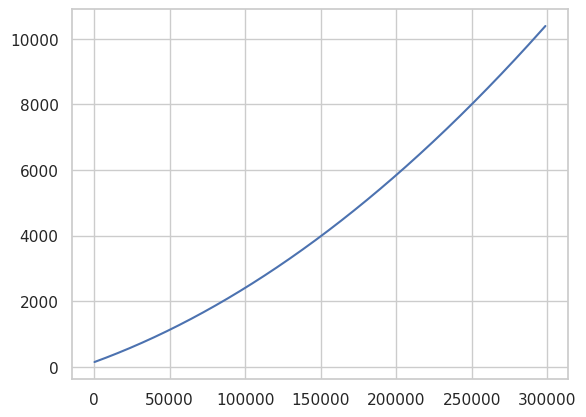

In [71]:
print(swp.isel(azimuth=0)["gate_height"].values)
print(swp.isel(azimuth=0)["range"].values)

plt.plot(swp.isel(azimuth=0)["range"].values, swp.isel(azimuth=0)["gate_height"].values)
plt.show()

In [72]:
import pysoundings

stnm, year, month, day_hour = '80222', '2024', '10', '2112'
data, units = pysoundings.get_data(stnm, year, month, day_hour)
print(data)



      PRES     HGHT  TEMP  DWPT  RELH   MIXR   DRCT  SKNT   THTA   THTE   THTV
0   1000.0    118.0   NaN   NaN   NaN    NaN    NaN   NaN    NaN    NaN    NaN
1    925.0    743.0   NaN   NaN   NaN    NaN    NaN   NaN    NaN    NaN    NaN
2    850.0   1513.0   NaN   NaN   NaN    NaN    NaN   NaN    NaN    NaN    NaN
3    752.0   2546.0  13.6  10.6  82.0  10.79    0.0   0.0  311.1  344.4  313.1
4    741.0   2672.0  11.6   9.8  89.0  10.37    9.0   1.0  310.2  342.2  312.1
..     ...      ...   ...   ...   ...    ...    ...   ...    ...    ...    ...
95    30.0  23850.0 -56.9 -88.9   1.0   0.00  240.0  23.0  588.9  589.0  588.9
96    29.0  24066.0 -54.9 -88.0   1.0   0.01  230.0  26.0  600.1  600.1  600.1
97    28.1  24268.0 -53.1 -87.1   1.0   0.01  237.0  29.0  610.6  610.7  610.6
98    27.1  24501.0 -53.5 -86.5   1.0   0.01  244.0  32.0  615.8  615.9  615.8
99    27.0      NaN   NaN   NaN   NaN    NaN  245.0  32.0    NaN    NaN    NaN

[100 rows x 11 columns]


In [73]:
with open('metadata/2025/05/01.json', 'r') as f:
    data = json.load(f)

# Fix get_stacks to avoid TypeError
def get_stacks(json_data):
    all_stacks = []
    current_stack = []
    last_sweep_elangle = float('inf')

    for station, station_data in json_data.items():
        for key, value in station_data.items():
            sweep_elangle = value['sweeps'][list(value['sweeps'].keys())[0]]['elevation_angle']
            current_sweep_elangle = float(sweep_elangle)

            if current_sweep_elangle <= last_sweep_elangle:
                if current_stack:
                    all_stacks.append(current_stack)
                current_stack = []

            current_stack.append(value['filepath'])
            last_sweep_elangle = float(value['sweeps'][list(value['sweeps'].keys())[-1]]['elevation_angle'])

        if current_stack:
            all_stacks.append(current_stack)

    return all_stacks

stacks = get_stacks(data)

In [74]:
print(len(stacks))

3186


In [75]:
lowest_ppi = []
for volume in stacks:
    lowest_ppi.append(volume[0])

lowest_ppi = np.array(lowest_ppi)
print(lowest_ppi.shape)

(3186,)


In [76]:
hour=[]
for ppi in lowest_ppi:
    hour.append(ppi[-14:-12])

hour = np.array(hour)
print(hour.shape)

(3186,)


In [77]:
lowest_ppi = lowest_ppi[hour == '01']
print(lowest_ppi)

['s3://s3-radaresideam/l2_data/2025/05/01/Barrancabermeja/BAR250501010005.RAW01ZC'
 's3://s3-radaresideam/l2_data/2025/05/01/Barrancabermeja/BAR250501010504.RAWFA51'
 's3://s3-radaresideam/l2_data/2025/05/01/Barrancabermeja/BAR250501011005.RAWFA6B'
 's3://s3-radaresideam/l2_data/2025/05/01/Barrancabermeja/BAR250501011505.RAWFA7N'
 's3://s3-radaresideam/l2_data/2025/05/01/Barrancabermeja/BAR250501012004.RAWFA90'
 's3://s3-radaresideam/l2_data/2025/05/01/Barrancabermeja/BAR250501012504.RAWFAAA'
 's3://s3-radaresideam/l2_data/2025/05/01/Barrancabermeja/BAR250501013004.RAWFABH'
 's3://s3-radaresideam/l2_data/2025/05/01/Barrancabermeja/BAR250501013504.RAWFACK'
 's3://s3-radaresideam/l2_data/2025/05/01/Barrancabermeja/BAR250501014004.RAWFADZ'
 's3://s3-radaresideam/l2_data/2025/05/01/Barrancabermeja/BAR250501014504.RAWFAFJ'
 's3://s3-radaresideam/l2_data/2025/05/01/Barrancabermeja/BAR250501015004.RAWFAGY'
 's3://s3-radaresideam/l2_data/2025/05/01/Barrancabermeja/BAR250501015504.RAWFAJ7'
 's3

In [ ]:
print(lowest_ppi[24:60])

['s3://s3-radaresideam/l2_data/2025/05/01/Corozal/COR250501010002.RAWFA3A'
 's3://s3-radaresideam/l2_data/2025/05/01/Corozal/COR250501010002.RAWFA4D'
 's3://s3-radaresideam/l2_data/2025/05/01/Corozal/COR250501010029.RAWFA3E'
 's3://s3-radaresideam/l2_data/2025/05/01/Corozal/COR250501010503.RAWFA4M'
 's3://s3-radaresideam/l2_data/2025/05/01/Corozal/COR250501010503.RAWFA5P'
 's3://s3-radaresideam/l2_data/2025/05/01/Corozal/COR250501010529.RAWFA4S'
 's3://s3-radaresideam/l2_data/2025/05/01/Corozal/COR250501011002.RAWFA5Z'
 's3://s3-radaresideam/l2_data/2025/05/01/Corozal/COR250501011002.RAWFA71'
 's3://s3-radaresideam/l2_data/2025/05/01/Corozal/COR250501011028.RAWFA62'
 's3://s3-radaresideam/l2_data/2025/05/01/Corozal/COR250501011503.RAWFA79'
 's3://s3-radaresideam/l2_data/2025/05/01/Corozal/COR250501011503.RAWFA8C'
 's3://s3-radaresideam/l2_data/2025/05/01/Corozal/COR250501011529.RAWFA7D'
 's3://s3-radaresideam/l2_data/2025/05/01/Corozal/COR250501012003.RAWFA8M'
 's3://s3-radaresideam/l2

In [ ]:
# Variables globals (es defineixen fora per estalviar memòria)
fs = s3fs.S3FileSystem(anon=True) 

# SUPOSICIÓ: 'dem' ja ha estat carregat en una cel·la prèvia i el tens en memòria amb xarray/rioxarray.
dem_lon = dem.x.values
dem_lat = dem.y.values

# Si les latituds van de nord a sud, invertim per a interpn
if dem_lat[0] > dem_lat[-1]:
    dem_lat_fix = dem_lat[::-1]
    dem_values_fix = elevation.values[::-1, :]
else:
    dem_lat_fix = dem_lat
    dem_values_fix = elevation.values

# =========================================================================
# 1. INICIALITZACIÓ DE MATRIUS GLOBALS PER A L'ACUMULACIÓ DE LA HORA
# =========================================================================
R_acumulada_A = None
R_acumulada_Z = None

gate_lat_ref = None
gate_lon_ref = None

print(f"Iniciant processament horari: {len(lowest_ppi[1:12])} fitxers a integrar...")

# =========================================================================
# 2. BUCLE PRINCIPAL DE PROCESAMENT DELS SCANS
# =========================================================================
for i, s3_path in enumerate(lowest_ppi[24:60]):
    try:
        print(f"  [{i+1}/12] Processant: {s3_path.split('/')[-1]}")
        
        # Obertura de l'arxiu
        bytes_en_memoria = io.BytesIO(fs.cat(s3_path))
        dtree = open_iris_dtree(bytes_en_memoria, decode_hclass=False)
        swp = dtree["/sweep_0"]
        
        # Extracció de l'altitud de la torre i geometria base
        radar_alt = float(dtree["/"]["altitude"].values)
        radar_lon = float(dtree["/"]["longitude"].values)
        radar_lat = float(dtree["/"]["latitude"].values)

        site = (radar_lon, radar_lat, radar_alt)

        azimuth = swp["azimuth"].data
        r_distances = swp["range"].data
        elangle = swp["elevation"].data

        azimuth_2d, range_2d = np.meshgrid(azimuth, r_distances, indexing='ij')
        elevation_2d = np.broadcast_to(elangle[:,np.newaxis], azimuth_2d.shape)

        xyz, aeqd = wrl.georef.polar.spherical_to_xyz(range_2d, azimuth_2d, elevation_2d, site)

        transformer = Transformer.from_crs(aeqd, "EPSG:4326", always_xy=True)
        lon, lat = transformer.transform(xyz[...,0], xyz[...,1])

        radar_lon_matrix = np.squeeze(lon)
        radar_lat_matrix = np.squeeze(lat)
        radar_z_matrix = np.squeeze(xyz[...,2])

        # A la primera passada d'un arxiu de l'hora, extraiem el format i assignem geometria base global
        if R_acumulada_A is None:
            R_acumulada_A = np.zeros_like(radar_lon_matrix)
            R_acumulada_Z = np.zeros_like(radar_lon_matrix)
            gate_lat_ref = radar_lat_matrix
            gate_lon_ref = radar_lon_matrix

        swp.coords["gate_latitude"] = (('azimuth', 'range'), radar_lat_matrix)
        swp.coords["gate_longitude"] = (('azimuth', 'range'), radar_lon_matrix)
        swp.coords["gate_height"] = (('azimuth', 'range'), radar_z_matrix)

        # Variables base
        DBZH = swp["DBZH"]
        PHIDP = swp["PHIDP"]
        KDP = swp["KDP"]
        RHOHV = swp["RHOHV"]
        ZDR = swp["ZDR"]

        # -----------------------------------------------------
        # BLOC DE TERRENY I BLOQUEIG FÍSIC
        # -----------------------------------------------------
        forma_original_radar = radar_lat_matrix.shape
        punts_radar = np.stack((radar_lat_matrix, radar_lon_matrix), axis=-1).reshape(-1, 2)
        
        terrain_height_flat = interpn(
            (dem_lat_fix, dem_lon), 
            dem_values_fix, 
            punts_radar, 
            method="linear", 
            bounds_error=False, 
            fill_value=-500.0
        )
        
        terrain_height = terrain_height_flat.reshape(forma_original_radar)
        terrain_height = np.nan_to_num(terrain_height, nan=-500.0)

        beamwidth = 1.0
        beamradius = wrl.util.half_power_radius(r_distances, beamwidth)

        gate_height_corregit = radar_z_matrix.copy()

        pbb = wrl.qual.beam_block_frac(terrain_height, gate_height_corregit, beamradius)

        # Proteccions de geometria per evitar ombres artificials (mar/plana)
        pbb[terrain_height <= 0.0] = 0.0
        pbb[gate_height_corregit > (terrain_height + beamradius)] = 0.0
        _, range_2d_temp = np.meshgrid(swp["azimuth"].data, r_distances, indexing='ij')
        pbb[range_2d_temp < 3000.0] = 0.0

        pbb_masked = np.ma.masked_invalid(pbb)
        cbb = wrl.qual.cum_beam_block_frac(pbb_masked)
        cbb = np.ma.filled(cbb, fill_value=0.0)

        dbzh_raw = DBZH.values
        dbzh_corr = np.copy(dbzh_raw)
        mask_comp = (cbb >= 0.1) & (cbb <= 0.5)
        dbzh_corr[mask_comp] = dbzh_corr[mask_comp] - 10.0 * np.log10(1.0 - cbb[mask_comp])
        mask_elim = cbb > 0.5
        dbzh_corr[mask_elim] = np.nan

        DBZH_terrain_corr = xr.DataArray(dbzh_corr, dims=["azimuth", "range"])

        # -----------------------------------------------------
        # MÀSCARA CLUTTER DUAL POLARIZATION (KILAMBI)
        # -----------------------------------------------------
        textura_phidp = wrl.util.texture(PHIDP.values)
        textura_phidp = np.nan_to_num(textura_phidp, nan=0.0)
        tPHIDP = xr.DataArray(textura_phidp, dims=PHIDP.dims, coords=PHIDP.coords)

        zdr_linear = 10.0 ** (ZDR.values / 10.0)
        zdr_sqrt_linear = 10.0 ** (ZDR.values / 20.0)
        numerador = zdr_linear + 1.0 - (2.0 * zdr_sqrt_linear * RHOHV.values)
        denominador = zdr_linear + 1.0 + (2.0 * zdr_sqrt_linear * RHOHV.values)

        with np.errstate(divide='ignore', invalid='ignore'):
            dr_linear = numerador / denominador
            dr_db = 10.0 * np.log10(dr_linear)

        DR = xr.DataArray(dr_db, dims=["azimuth","range"]).fillna(0.0)

        no_met_mask = (
            ((DR > -12.0) & (DBZH < 30.0))
            | ((tPHIDP > 22.5) & (DBZH < 35.0))
            | (DBZH <= 0)
        )

        structure = generate_binary_structure(rank=2, connectivity=1)
        clean_clutter_mask = binary_opening(no_met_mask.values, structure=structure, iterations=1)
        met_mask = xr.DataArray(~clean_clutter_mask, dims=swp.DBZH.dims, coords=swp.DBZH.coords)

        # -----------------------------------------------------
        # KDP & ATENUACIÓ (REESTRUCTURACIÓ NUMÈRICA RÀPIDA)
        # -----------------------------------------------------
        fDBZH = xr.where(met_mask, DBZH_terrain_corr, np.nan).interpolate_na(dim="range", method="linear", max_gap=8)
        fPHIDP = xr.where(met_mask, PHIDP, np.nan)
        
        phidp_inicial = fPHIDP.copy()
        vals_mediana = median_filter(phidp_inicial.values, size=(1, 5))
        phidp_mediana = xr.DataArray(vals_mediana, dims=phidp_inicial.dims, coords=phidp_inicial.coords)
        
        sPHIDP = phidp_mediana.rolling(range=25, center=True, min_periods=1).mean().fillna(0.0)

        vals = np.copy(sPHIDP.values)
        for az in np.arange(vals.shape[0]):
            ray = vals[az]
            for j in np.arange(1, len(ray)):
                if np.isfinite(ray[j-1]) and np.isfinite(ray[j]):
                    if ray[j] < ray[j-1]:
                        ray[j] = ray[j-1]
            vals[az] = ray

        vals = median_filter(vals, size=(1, 4))
        vals = median_filter(vals, size=(1, 8))
        
        vals_with_nan = np.copy(vals)
        vals_with_nan[~met_mask.values] = np.nan
        sPHIDP_final = xr.DataArray(vals_with_nan, dims=fPHIDP.dims, coords=fPHIDP.coords)

        dr_km = float(swp["range"][1] - swp["range"][0]) / 1000.0

        dKDP_calculat = wrl.dp.kdp_from_phidp(
            sPHIDP_final.values, 
            winlen=25,
            dr=dr_km,
            method="lanczos_conv"
        )
        
        dKDP_net = np.where(dKDP_calculat < 0.0, 0.0, dKDP_calculat)
        dKDP_net = median_filter(dKDP_net, size=(1, 3))
        dKDP_final = np.copy(dKDP_net)
        dKDP_final[~met_mask.values] = np.nan

        # Càlcul d'Atenuació
        alpha = 0.01
        A = alpha * dKDP_final
        pia_vals = 2 * np.nancumsum(A * dr_km, axis=1)
        cDBZH_attcorr = fDBZH.values + pia_vals

        # -----------------------------------------------------
        # EXTRACCIÓ I INTEGRACIÓ DE PLUJA HORÀRIA
        # -----------------------------------------------------
        # Es netegen de NaNs per poder fer la suma matricial matemàtica
        R_A_instant = 4120 * (A ** 1.03)
        R_A_instant = np.nan_to_num(R_A_instant, nan=0.0)
        
        R_Z_instant = (10**(cDBZH_attcorr/10)/180)**(1/1.4)
        R_Z_instant = np.nan_to_num(R_Z_instant, nan=0.0)

        # Si estem fent un scan cada 5 minuts -> Multipliquem la taxa instantània x (5 min / 60 min)
        fraccio_hora = 5.0 / 60.0
        R_acumulada_A += (R_A_instant * fraccio_hora)
        R_acumulada_Z += (R_Z_instant * fraccio_hora)

    except Exception as e:
        print(f"  [ERROR] Procesant el fitxer {s3_path}: {e}")
        continue

print("=========================================")
print("ACUMULACIÓ HORÀRIA (1 HORA) COMPLETADA")
print(f"Max Pluja Acumulada R_Z: {np.max(R_acumulada_Z):.2f} mm")
print(f"Max Pluja Acumulada R_A: {np.max(R_acumulada_A):.2f} mm")

# =========================================================================
# 3. VALIDACIÓ AMB ESTACIONS (Lògica al final del bucle)
# =========================================================================
# Aquest fragment és assumint que tens el teu DataFrame d'estacions (hourly_geo_df) obert en el notebook.

hora_a_extreure = 0  # HORA=00 (Canvia-ho pel mateix que lowest_ppi[hour == '00'])

try:
    df_filtrat = hourly_geo_df[hourly_geo_df['fechaobservacion'].dt.hour == hora_a_extreure].copy()
    df_filtrat = df_filtrat.dropna(subset=["longitud", "latitud", "acumulado_horario"])

    print(f"Realitzant validació de {len(df_filtrat)} estacions...")

    # Acumuladors d'errors per mètriques
    estacion_vals = []
    radar_z_vals = []
    radar_a_vals = []

    for idx, row in df_filtrat.iterrows():
        lat_est = row['latitud']
        lon_est = row['longitud']
        pluja_real = row['acumulado_horario']

        # Distància Euclídea per a Neighbor Search en memòria matricial
        dist_matrix = np.sqrt((gate_lat_ref - lat_est)**2 + (gate_lon_ref - lon_est)**2)
        idx_min = np.unravel_index(np.argmin(dist_matrix), dist_matrix.shape)

        pluja_radar_z = R_acumulada_Z[idx_min]
        pluja_radar_a = R_acumulada_A[idx_min]

        estacion_vals.append(pluja_real)
        radar_z_vals.append(pluja_radar_z)
        radar_a_vals.append(pluja_radar_a)

    # Càlcul de mètriques
    estacion_vals = np.array(estacion_vals)
    radar_z_vals = np.array(radar_z_vals)
    radar_a_vals = np.array(radar_a_vals)

    rmse_z = np.sqrt(np.mean((radar_z_vals - estacion_vals)**2))
    bias_z = np.mean(radar_z_vals - estacion_vals)

    rmse_a = np.sqrt(np.mean((radar_a_vals - estacion_vals)**2))
    bias_a = np.mean(radar_a_vals - estacion_vals)

    print("\n--- RESULTATS DE LA VALIDACIÓ (ESTACIONS VS RADAR) ---")
    print(f"Mètrica tradicional Marshall-Palmer Z-R (R_Z): RMSE={rmse_z:.2f} mm | Bias={bias_z:.2f} mm")
    print(f"Mètrica d'Atenuació Específica (R_A):        RMSE={rmse_a:.2f} mm | Bias={bias_a:.2f} mm")

except Exception as e:
    print(f"No s'ha pogut procedir amb la validació: {e}")

Iniciant processament horari: 11 fitxers a integrar...
  [1/12] Processant: COR250501010002.RAWFA3A


  [ERROR] Procesant el fitxer s3://s3-radaresideam/l2_data/2025/05/01/Corozal/COR250501010002.RAWFA3A: There are 19200 points and 1920 values in dimension 0
  [2/12] Processant: COR250501010002.RAWFA4D
  [ERROR] Procesant el fitxer s3://s3-radaresideam/l2_data/2025/05/01/Corozal/COR250501010002.RAWFA4D: 'Could not find node at DB_HCLASS'
  [3/12] Processant: COR250501010029.RAWFA3E
  [ERROR] Procesant el fitxer s3://s3-radaresideam/l2_data/2025/05/01/Corozal/COR250501010029.RAWFA3E: There are 19200 points and 1920 values in dimension 0
  [4/12] Processant: COR250501010503.RAWFA4M
  [ERROR] Procesant el fitxer s3://s3-radaresideam/l2_data/2025/05/01/Corozal/COR250501010503.RAWFA4M: There are 19200 points and 1920 values in dimension 0
  [5/12] Processant: COR250501010503.RAWFA5P
  [ERROR] Procesant el fitxer s3://s3-radaresideam/l2_data/2025/05/01/Corozal/COR250501010503.RAWFA5P: 'Could not find node at DB_HCLASS'
  [6/12] Processant: COR250501010529.RAWFA4S
  [ERROR] Procesant el fitxe

In [95]:
R_acumulada_A[R_acumulada_A == 0] = np.nan

In [96]:
da = xr.DataArray(
    R_acumulada_A,
    dims=swp["R_A"].dims,
    coords=swp["R_A"].coords,
)

print(da)

da.attrs["sweep_mode"] = swp["sweep_mode"].values
da.coords["longitude"] = dtree["longitude"].values
da.coords["latitude"] = dtree["latitude"].values
da.coords["altitude"] = dtree["altitude"].values
da_geo = da.wrl.georef.georeference()
fig = plt.figure(figsize=(20,10))       
ax = fig.add_subplot(111, projection=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values))

ax.set_facecolor('xkcd:light gray') 

plot_features(ax)
da_geo.plot.pcolormesh(
    x="x",
    y="y",
    ax=ax,
    vmin=0,
    vmax=60,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    transform=ccrs.AzimuthalEquidistant(central_longitude=da.longitude.values, central_latitude=da.latitude.values),
    add_colorbar=False,
    alpha=0.75
)

hourly_geo_df = hourly_geo_df.dropna(subset=["longitud", "latitud", "acumulado_horario"])

hora_a_plotejar = 7

hour_geo_df = hourly_geo_df[hourly_geo_df['fechaobservacion'].dt.hour == hora_a_plotejar].copy()

print(hour_geo_df)

print(f"Plotting {len(hour_geo_df)} points")
#print(f"Lon range: {hourly_geo_df['longitud'].min():.4f} to {hourly_geo_df['longitud'].max():.4f}")
#print(f"Lat range: {hourly_geo_df['latitud'].min():.4f} to {hourly_geo_df['latitud'].max():.4f}")

# ---- Center projection on the data ----
#center_lon = filtered_df["longitud"].mean()
#center_lat = filtered_df["latitud"].mean()

# ---- Map features ----
department_lines = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    edgecolor='black',
    facecolor='never',
    linewidth=0.6
)

# ---- Separar según valor observado ----
zeros = hour_geo_df[hourly_geo_df["acumulado_horario"] == 0]
nonzeros = hour_geo_df[hourly_geo_df["acumulado_horario"] > 0]
print(zeros)

# ---- Dibujar puntos con precipitación >0 (relleno con colormap) ----
sc = ax.scatter(
    nonzeros["longitud"],
    nonzeros["latitud"],
    c=nonzeros["acumulado_horario"],
    vmin=0,
    vmax=60,
    cmap=cmap.Colormap("ncar").to_mpl(number_of_colors),
    s=50,
    edgecolors="red",
    linewidth=0.9,
    alpha=0.9,
    transform=ccrs.PlateCarree(),
    zorder=1,
)

# ---- Dibujar puntos con valor == 0 (solo borde, sin relleno) ----
ax.scatter(
    zeros["longitud"],
    zeros["latitud"],
    facecolors="none",
    edgecolors="black",
    s=20,
    linewidth=0.5,
    alpha=0.7,
    transform=ccrs.PlateCarree(),
    zorder=2,
)

cb = plt.colorbar(sc,ax=ax,extend="max")

# ---- Adjust map extent to data bounds with a small margin ----
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

proj_crs = ccrs.AzimuthalEquidistant(
    central_longitude=da.longitude.values, 
    central_latitude=da.latitude.values
)

# 2. Your existing wradlib call
wrl.vis.plot_ppi_crosshair(
    site=site,
    ranges=ranges,
    line={"color": "None"},
    circle={"edgecolor": "black", "linewidth" : 1, "linestyle" : "-"},
    ax=ax,
    crs=proj_crs,
)

# 3. Add the text labels
# Choose an angle to place the text (e.g., 45 degrees, top-right quadrant)
angle_deg = 45 
angle_rad = np.radians(angle_deg)

for r in ranges:
    # Calculate x and y coordinates in meters from the center
    # In meteorology, 0 degrees is usually North. 
    # So x = r * sin(angle), y = r * cos(angle)
    x = r * np.sin(angle_rad)
    y = r * np.cos(angle_rad)
    
    # Format the label to km for readability (e.g., "12.5 km")
    label_text = f"{r / 1000:g} km"
    
    # Plot the text
    ax.text(
        x, y, label_text,
        transform=proj_crs,         # Ensures it maps to your cartopy projection correctly
        fontsize=9,
        ha='center',                # Horizontally center the text on the coordinate
        va='center',                # Vertically center the text on the coordinate
        color='black',
        # Adding a small, semi-transparent white box behind the text makes it 
        # readable even if it overlaps with intense radar echoes.
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5) 
    )

plt.tight_layout()
plt.show()

KeyError: 'Could not find node at R_A'